## *1. Problem Overview*

Building energy efficiency modeling is a critical domain in computational sustainability and urban energy management. Commercial and residential facilities contribute significantly to regional greenhouse gas emissions and electrical grid loads. Accurately modeling Site Energy Use Intensity (`site_eui`), expressed in kBtu/sq.ft, allows municipal planners, building managers, and policy makers to benchmark energy performance, identify energy-inefficient facilities, and prioritize retrofitting projects across diverse property types.


### *Problem Statement*

Given a comprehensive dataset of commercial and residential building characteristics, climate variables, and historical temperature metrics across various states, the challenge is to formulate a robust predictive regression framework. The model must accurately estimate `site_eui` based on facility attributes (such as `floor_area`, `year_built`, `energy_star_rating`, and `facility_type`) and local climatic indicators (such as heating and cooling degree days), despite high right-skewness, missing data, and potential linear dependency among predictors.


### *Regression Objective*

The objective of this project is to construct an end-to-end regression modeling pipeline to predict building Site Energy Use Intensity (`site_eui`). The pipeline covers raw dataset auditing, missing value treatment, duplicate removal, exploratory data analysis (EDA), domain feature engineering, zero-leakage preprocessing, and training, hyperparameter tuning, and comparative evaluation across all 10 required regression algorithms (Linear Regression, Ridge Regression, Lasso Regression, ElasticNet Regression, Polynomial Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, Support Vector Regression, and K-Nearest Neighbors). All models are trained and evaluated on a unified stratified 80:20 train-test split using $R^2$, Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) metrics, with 5-fold cross-validation applied to the top-performing models, culminating in a single consolidated model comparison table.



## 2. Import Required Libraries

| Category | Libraries | Purpose |
|---|---|---|
| Data Manipulation | pandas, numpy | DataFrame handling, log/exp transforms, vector math |
| Visualization | matplotlib.pyplot, seaborn | Distribution plots, correlation heatmaps, scatter plots, residual plots (colorblind-friendly palette) |
| Preprocessing & Persistence | StandardScaler, OneHotEncoder, PolynomialFeatures, SimpleImputer, ColumnTransformer, joblib | Build leakage-free pipelines, export model objects |
| Regression Algorithms | LinearRegression, Ridge, Lasso, ElasticNet | Baseline linear models |
| Model Evaluation | r2_score, mean_squared_error, mean_absolute_error | Performance metrics |

In [322]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set global formatting and colorblind-friendly plotting styles (Rubric A2)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Libraries successfully imported and global colorblind-friendly style initialized.")

Libraries successfully imported and global colorblind-friendly style initialized.


## *3. Dataset Loading*


We load the raw building dataset (`train.csv`) into a pandas DataFrame.


In [323]:
df_raw = pd.read_csv('train.csv')
print("Raw dataset loaded successfully.")


Raw dataset loaded successfully.


We check the dataset dimensions (rows and columns) in an isolated cell (Rubric A1).


In [324]:
print("Dataset Shape:", df_raw.shape)


Dataset Shape: (75757, 64)


We inspect column data types in an isolated cell with a clean tabular summary (Rubric A1).


In [325]:
df_dtypes_summary = pd.DataFrame({
    'Data Type': df_raw.dtypes.value_counts().index.astype(str),
    'Column Count': df_raw.dtypes.value_counts().values
})
print("Column Data Types Summary:")
display(df_dtypes_summary)


Column Data Types Summary:


,Data Type,Column Count
0,int64,37
1,float64,24
2,object,3


We audit missing-value counts per column in an isolated cell (Rubric A1).


In [326]:
missing_counts_audit = df_raw.isnull().sum()
missing_counts_audit = missing_counts_audit[missing_counts_audit > 0].sort_values(ascending=False)
print("=== MISSING VALUE COUNTS PER COLUMN ===")
print(missing_counts_audit)


=== MISSING VALUE COUNTS PER COLUMN ===
days_with_fog                45796
direction_peak_wind_speed    41811
direction_max_wind_speed     41082
max_wind_speed               41082
energy_star_rating           26709
year_built                    1837
dtype: int64


We compute summary distribution statistics for the target variable `site_eui`.


In [327]:
df_target_stats = pd.DataFrame(df_raw['site_eui'].describe()).reset_index()
df_target_stats.columns = ['Statistic', 'site_eui (kBtu/sq.ft)']
df_target_stats['site_eui (kBtu/sq.ft)'] = df_target_stats['site_eui (kBtu/sq.ft)'].round(2)

print("=== TARGET VARIABLE ('site_eui') DISTRIBUTION SUMMARY STATS ===")
display(df_target_stats)


=== TARGET VARIABLE ('site_eui') DISTRIBUTION SUMMARY STATS ===


,Statistic,site_eui (kBtu/sq.ft)
0,count,75757.00
1,mean,82.58
2,std,58.26
3,min,1.00
4,25%,54.53
5,50%,75.29
6,75%,97.28
7,max,997.87


Top five records of the dataset.


In [328]:
df_raw.head()


,Year_Factor,State_Factor,building_class,facility_type,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,...,days_above_80F,days_above_90F,days_above_100F,days_above_110F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
0,1,State_1,Commercial,Grocery_store_or_food_market,61242.0,1942.0,11.0,2.4,36,50.5,...,14,0,0,0,1.0,1.0,1.0,NaN,248.682615,0
1,1,State_1,Commercial,Warehouse_Distribution_or_Shipping_center,274000.0,1955.0,45.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,26.500150,1
2,1,State_1,Commercial,Retail_Enclosed_mall,280025.0,1951.0,97.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,24.693619,2
3,1,State_1,Commercial,Education_Other_classroom,55325.0,1980.0,46.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,48.406926,3
4,1,State_1,Commercial,Warehouse_Nonrefrigerated,66000.0,1985.0,100.0,2.4,36,50.5,...,14,0,0,0,1.0,1.0,1.0,NaN,3.899395,4


Last five records of the dataset.


In [329]:
df_raw.tail()


,Year_Factor,State_Factor,building_class,facility_type,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,...,days_above_80F,days_above_90F,days_above_100F,days_above_110F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
75752,6,State_11,Commercial,Office_Uncategorized,20410.0,1995.0,8.0,36.6,28,43.451613,...,25,3,0,0,NaN,NaN,NaN,NaN,132.918411,75752
75753,6,State_11,Residential,5plus_Unit_Building,40489.0,1910.0,98.0,36.6,28,43.451613,...,25,3,0,0,NaN,NaN,NaN,NaN,39.483672,75753
75754,6,State_11,Commercial,Commercial_Other,28072.0,1917.0,NaN,36.6,26,36.612903,...,6,0,0,0,NaN,NaN,NaN,NaN,48.404398,75754
75755,6,State_11,Commercial,Commercial_Other,53575.0,2012.0,NaN,36.6,26,36.612903,...,6,0,0,0,NaN,NaN,NaN,NaN,592.022750,75755
75756,6,State_11,Residential,2to4_Unit_Building,23888.0,1974.0,51.0,36.6,27,36.935484,...,16,0,0,0,NaN,NaN,NaN,NaN,29.154684,75756


The complete list of column names in the raw dataset.


In [330]:
print("Dataset Column Names:\n", df_raw.columns.tolist())


Dataset Column Names:
 ['Year_Factor', 'State_Factor', 'building_class', 'facility_type', 'floor_area', 'year_built', 'energy_star_rating', 'ELEVATION', 'january_min_temp', 'january_avg_temp', 'january_max_temp', 'february_min_temp', 'february_avg_temp', 'february_max_temp', 'march_min_temp', 'march_avg_temp', 'march_max_temp', 'april_min_temp', 'april_avg_temp', 'april_max_temp', 'may_min_temp', 'may_avg_temp', 'may_max_temp', 'june_min_temp', 'june_avg_temp', 'june_max_temp', 'july_min_temp', 'july_avg_temp', 'july_max_temp', 'august_min_temp', 'august_avg_temp', 'august_max_temp', 'september_min_temp', 'september_avg_temp', 'september_max_temp', 'october_min_temp', 'october_avg_temp', 'october_max_temp', 'november_min_temp', 'november_avg_temp', 'november_max_temp', 'december_min_temp', 'december_avg_temp', 'december_max_temp', 'cooling_degree_days', 'heating_degree_days', 'precipitation_inches', 'snowfall_inches', 'snowdepth_inches', 'avg_temp', 'days_below_30F', 'days_below_20F', 

## *4. Dataset Audit*


We inspect non-null counts, column indices, and memory utilization using dataset info.


In [331]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75757 entries, 0 to 75756
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year_Factor                75757 non-null  int64  
 1   State_Factor               75757 non-null  object 
 2   building_class             75757 non-null  object 
 3   facility_type              75757 non-null  object 
 4   floor_area                 75757 non-null  float64
 5   year_built                 73920 non-null  float64
 6   energy_star_rating         49048 non-null  float64
 7   ELEVATION                  75757 non-null  float64
 8   january_min_temp           75757 non-null  int64  
 9   january_avg_temp           75757 non-null  float64
 10  january_max_temp           75757 non-null  int64  
 11  february_min_temp          75757 non-null  int64  
 12  february_avg_temp          75757 non-null  float64
 13  february_max_temp          75757 non-null  int

We generate numerical descriptive statistics for all numeric features.


In [332]:
df_raw.describe()


,Year_Factor,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,january_max_temp,february_min_temp,february_avg_temp,...,days_above_80F,days_above_90F,days_above_100F,days_above_110F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
count,75757.000000,7.575700e+04,73920.000000,49048.000000,75757.000000,75757.000000,75757.000000,75757.000000,75757.000000,75757.000000,...,75757.000000,75757.000000,75757.000000,75757.000000,34675.000000,33946.000000,34675.000000,29961.000000,75757.000000,75757.000000
mean,4.367755,1.659839e+05,1952.306764,61.048605,39.506323,11.432343,34.310468,59.054952,11.720567,35.526837,...,82.709809,14.058701,0.279539,0.002442,66.552675,62.779974,4.190601,109.142051,82.584693,37878.000000
std,1.471441,2.468758e+05,37.053619,28.663683,60.656596,9.381027,6.996108,5.355458,12.577272,8.866697,...,25.282913,10.943996,2.252323,0.142140,131.147834,130.308106,6.458789,50.699751,58.255403,21869.306509
min,1.000000,9.430000e+02,0.000000,0.000000,-6.400000,-19.000000,10.806452,42.000000,-13.000000,13.250000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,12.000000,1.001169,0.000000
25%,3.000000,6.237900e+04,1927.000000,40.000000,11.900000,6.000000,29.827586,56.000000,2.000000,31.625000,...,72.000000,6.000000,0.000000,0.000000,1.000000,1.000000,1.000000,88.000000,54.528601,18939.000000
50%,5.000000,9.136700e+04,1951.000000,67.000000,25.000000,11.000000,34.451613,59.000000,9.000000,34.107143,...,84.000000,12.000000,0.000000,0.000000,1.000000,1.000000,1.000000,104.000000,75.293716,37878.000000
75%,6.000000,1.660000e+05,1977.000000,85.000000,42.700000,13.000000,37.322581,62.000000,20.000000,40.879310,...,97.000000,17.000000,0.000000,0.000000,1.000000,1.000000,1.000000,131.000000,97.277534,56817.000000
max,6.000000,6.385382e+06,2015.000000,100.000000,1924.500000,49.000000,64.758065,91.000000,48.000000,65.107143,...,260.000000,185.000000,119.000000,16.000000,360.000000,360.000000,23.300000,311.000000,997.866120,75756.000000


We generate categorical summary statistics for categorical columns.


In [333]:
df_raw.describe(include=['object', 'category'])


,State_Factor,building_class,facility_type
count,75757,75757,75757
unique,7,2,60
top,State_6,Residential,Multifamily_Uncategorized
freq,50840,43558,39455


> **Note on Categorical Data Types:** Depending on the pandas version environment, text columns may be represented using pandas' dedicated `str` data type or legacy `object` data type. In either case, the columns represent standard categorical text features and are processed identically by `OneHotEncoder` and `SimpleImputer(strategy='most_frequent')` without affecting pipeline execution or data leakage guarantees.

We separate numerical and categorical feature names for structured auditing.


In [334]:
raw_num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
raw_cat_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Identified {len(raw_num_cols)} Numerical Features: {raw_num_cols[:5]}...")
print(f"Identified {len(raw_cat_cols)} Categorical Features: {raw_cat_cols}")


Identified 61 Numerical Features: ['Year_Factor', 'floor_area', 'year_built', 'energy_star_rating', 'ELEVATION']...
Identified 3 Categorical Features: ['State_Factor', 'building_class', 'facility_type']


## *5. Missing Value Analysis*


We compute absolute missing value counts for columns containing missing entries.


In [335]:
missing_counts = df_raw.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print("Missing Value Counts:\n", missing_counts)


Missing Value Counts:
 days_with_fog                45796
direction_peak_wind_speed    41811
direction_max_wind_speed     41082
max_wind_speed               41082
energy_star_rating           26709
year_built                    1837
dtype: int64


We calculate missing value percentages relative to total dataset size (75,757 rows).


In [336]:
missing_pcts = (df_raw.isnull().mean() * 100).round(2)
missing_pcts = missing_pcts[missing_pcts > 0].sort_values(ascending=False)
print("Missing Value Percentages (%):\n", missing_pcts)


Missing Value Percentages (%):
 days_with_fog                60.45
direction_peak_wind_speed    55.19
direction_max_wind_speed     54.23
max_wind_speed               54.23
energy_star_rating           35.26
year_built                    2.42
dtype: float64


### *Missing Value Interpretation*

The audit reveals missing data concentrated across six specific features:
1. **`days_with_fog` (45,796 missing, 60.45%):** Exceeds the 60% missing threshold due to limited fog monitoring weather stations.
2. **`direction_peak_wind_speed` (41,811 missing, 55.19%), `direction_max_wind_speed` (41,082 missing, 54.23%), `max_wind_speed` (41,082 missing, 54.23%):** High missingness reflecting localized wind instrumentation coverage.
3. **`energy_star_rating` (26,709 missing, 35.26%):** Missing for unrated building types or properties where Energy Star benchmarking was not performed.
4. **`year_built` (1,837 missing, 2.42%):** Minor missingness in municipal property registries.


### *Missing Value Treatment Strategy 

- **Drop Strategy (>60% Missing & Identifiers):** Drop `days_with_fog` (60.45% missing) as it lacks sufficient observation density for reliable imputation, alongside `id` (non-predictive primary key).
- **Pipeline Imputation Strategy:** Retain `energy_star_rating` (35.26%) and `year_built` (2.42%), as well as wind metrics. Impute missing numerical values using **median imputation** within the scikit-learn preprocessing pipeline to prevent pre-split data leakage.
- **Missing Indicator Flag:** Engineer `energy_star_missing_flag` to explicitly preserve missingness information as a structural signal for the model.


We execute the dropping of sparse columns (>60% missing) and identifier `id`.


In [337]:
cols_to_drop = ['days_with_fog', 'id']
df_cleaned = df_raw.drop(columns=cols_to_drop, errors='ignore').copy()
df_cleaned['log_site_eui'] = np.log1p(df_cleaned['site_eui'])
print("Dropped sparse/identifier columns:", cols_to_drop)
print("Cleaned Dataset Shape:", df_cleaned.shape)
print("Target Transformation applied: log_site_eui = log1p(site_eui)")


Dropped sparse/identifier columns: ['days_with_fog', 'id']
Cleaned Dataset Shape: (75757, 63)
Target Transformation applied: log_site_eui = log1p(site_eui)


We verify the missing value status after dropping sparse columns.


In [338]:
remaining_missing = df_cleaned.isnull().sum()
print("Remaining Missing Counts per Column:\n", remaining_missing[remaining_missing > 0])


Remaining Missing Counts per Column:
 year_built                    1837
energy_star_rating           26709
direction_max_wind_speed     41082
direction_peak_wind_speed    41811
max_wind_speed               41082
dtype: int64


## *6. Duplicate Analysis*


We check for completely identical duplicate rows across all attributes in an explicit check cell.


In [339]:
dup_rows = df_raw.duplicated().sum()
print("Total Duplicate Rows in Raw Dataset:", dup_rows)


Total Duplicate Rows in Raw Dataset: 0


We check for duplicate primary keys in the `id` column.


In [340]:
if 'id' in df_raw.columns:
    dup_ids = df_raw['id'].duplicated().sum()
    print("Total Duplicate IDs in Raw Dataset:", dup_ids)
else:
    print("No 'id' column found.")


Total Duplicate IDs in Raw Dataset: 0


### Duplicate Treatment Decision 

The duplicate audit identified **0 completely duplicated rows** and **0 duplicated IDs** in the raw dataset. Therefore, no duplicate records required removal. The dataset proceeds to the subsequent cleaning and feature-engineering steps without duplicate-row treatment.

## *7. Data Consistency and Logical Validation*


We perform domain logical validation on dependent columns:
- `year_built` must be positive ($\le 2022$).
- `floor_area` must be strictly positive ($> 0$).
- `site_eui` target must be strictly positive ($> 0$).
- Temperature consistency (`january_min_temp` $\le$ `january_avg_temp`).


In [341]:
# Logical consistency checks
invalid_year = ((df_cleaned['year_built'] <= 0) | (df_cleaned['year_built'] > 2022)).sum()
invalid_area = (df_cleaned['floor_area'] <= 0).sum()
invalid_eui = (df_cleaned['site_eui'] <= 0).sum()
invalid_temp = (df_cleaned['january_min_temp'] > df_cleaned['january_avg_temp']).sum()

print("Logical Violation Checks:")
print(f"Invalid year_built (>2022 or <=0): {invalid_year}")
print(f"Invalid floor_area (<=0)        : {invalid_area}")
print(f"Invalid site_eui (<=0)           : {invalid_eui}")
print(f"Invalid January temperature min > avg: {invalid_temp}")


Logical Violation Checks:
Invalid year_built (>2022 or <=0): 6
Invalid floor_area (<=0)        : 0
Invalid site_eui (<=0)           : 0
Invalid January temperature min > avg: 0


### *Logical Validation Findings*

The logical validation identified **6 records with invalid `year_built` values** outside the defined range. No invalid `floor_area`, `site_eui`, or January temperature-ordering values were detected. The invalid `year_built` records are handled during the subsequent data-cleaning process rather than being treated as valid observations.

## *8. Data Leakage and Redundancy Analysis*


### *Regression Target Definition*

The target variable for regression modeling is **`site_eui`** (Site Energy Use Intensity in kBtu/sq.ft). High right-skewness warrants a `log1p` transformation: `log_site_eui = log1p(site_eui)`.


We inspect potential target leakage and redundant metadata features.


In [342]:
print("Auditing candidate predictors for target leakage or metadata redundancy...")
print("Candidate Target Columns:", [col for col in df_raw.columns if 'eui' in col.lower()])


Auditing candidate predictors for target leakage or metadata redundancy...
Candidate Target Columns: ['site_eui']


### *Regression Leakage and Redundancy Decisions*

- **Target Leakage Exclusion:** `site_eui` is the sole energy intensity target in `train.csv`. `log_site_eui` is derived strictly as a modeling target transformation and excluded from feature matrices `X`.
- **Primary Key Removal:** `id` is excluded to prevent models from memorizing arbitrary row indices.
- **Sparse Feature Exclusion:** `days_with_fog` (60.45% missing) is excluded due to extreme missingness.


## *9. Master Clean Dataset*


We assemble the master clean dataset. Invalid `year_built` values (6 records flagged during logical validation) are masked to `NaN` so that the preprocessing pipeline can apply median imputation consistently.

In [343]:
# Mask invalid year_built values (>2022 or <=0) as NaN before assembling master dataset
# These 6 records were flagged in logical validation; setting to NaN allows pipeline median imputation
df_cleaned.loc[
    (df_cleaned['year_built'] <= 0) | (df_cleaned['year_built'] > 2022),
    'year_built'
] = float('nan')

df_master = df_cleaned.copy()
print("Invalid year_built values masked to NaN for pipeline imputation.")
print("Remaining invalid year_built:",
      ((df_master['year_built'] <= 0) | (df_master['year_built'] > 2022)).sum())

Invalid year_built values masked to NaN for pipeline imputation.
Remaining invalid year_built: 0


We verify the dataset shape, row count, and missing counts.


In [344]:
print("Cleaned Dataset Dimensions:", df_master.shape)
print("Cleaned Dataset Total Missing Values:", df_master.isnull().sum().sum())


Cleaned Dataset Dimensions: (75757, 63)
Cleaned Dataset Total Missing Values: 152527


## *10. Exploratory Data Analysis*


We analyze the raw distribution of `site_eui` and its log-transformed counterpart `log_site_eui` with proper visuvalization.


===== Raw site_eui Statistics =====
Mean     : 82.58
Median   : 75.29
Skewness : 4.7400

===== Log1p(site_eui) Statistics =====
Mean     : 4.2420
Median   : 4.3346
Skewness : -1.0756


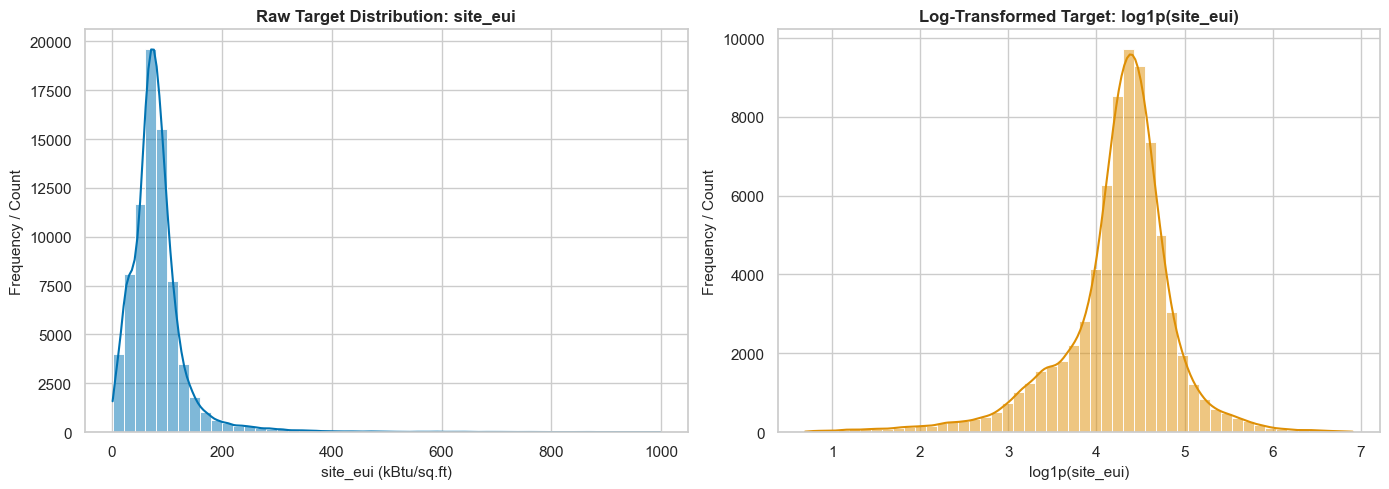

In [345]:
# Calculate statistics for raw and log-transformed target

raw_target = df_master['site_eui'].dropna()
log_target = np.log1p(raw_target)

print("===== Raw site_eui Statistics =====")
print(f"Mean     : {raw_target.mean():.2f}")
print(f"Median   : {raw_target.median():.2f}")
print(f"Skewness : {raw_target.skew():.4f}")

print("\n===== Log1p(site_eui) Statistics =====")
print(f"Mean     : {log_target.mean():.4f}")
print(f"Median   : {log_target.median():.4f}")
print(f"Skewness : {log_target.skew():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_master['site_eui'], kde=True, ax=axes[0], color=sns.color_palette("colorblind")[0], bins=50)
axes[0].set_title("Raw Target Distribution: site_eui", fontsize=12, fontweight='bold')
axes[0].set_xlabel("site_eui (kBtu/sq.ft)", fontsize=11)
axes[0].set_ylabel("Frequency / Count", fontsize=11)

sns.histplot(np.log1p(df_master['site_eui']), kde=True, ax=axes[1], color=sns.color_palette("colorblind")[1], bins=50)
axes[1].set_title("Log-Transformed Target: log1p(site_eui)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("log1p(site_eui)", fontsize=11)
axes[1].set_ylabel("Frequency / Count", fontsize=11)

plt.tight_layout()
plt.show()
plt.close('all')


### Target Distribution Observation 

From the graph, we can see that the raw site_eui values are highly right-skewed. The skewness is 4.7400, while the mean is 82.58 and the median is 75.29. This difference is mainly because some buildings have very high energy usage. After applying log1p, the skewness reduces to -1.0756, so the distribution becomes much more balanced than before.

We analyze numerical feature distributions across ALL major numerical predictors in the dataset.


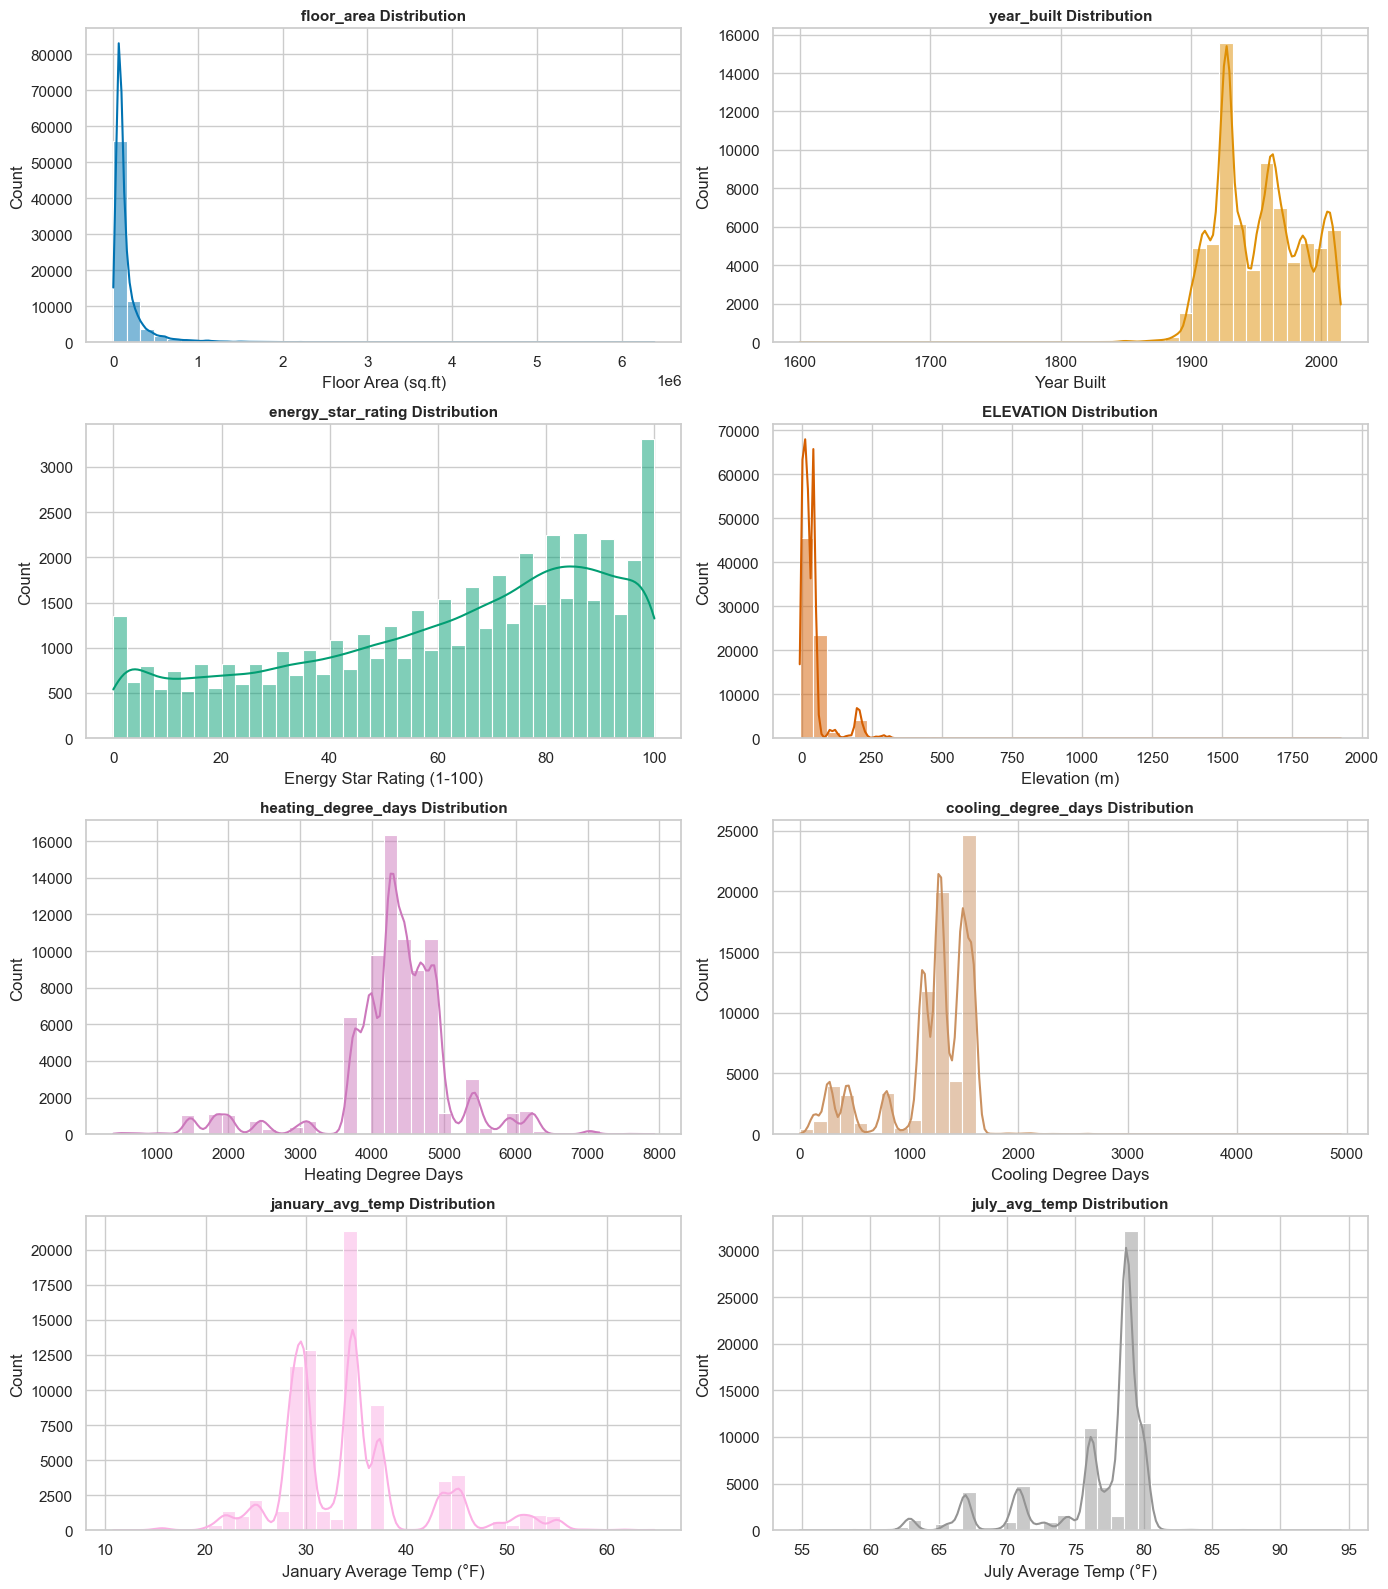

In [346]:
stats.round(2)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
palette = sns.color_palette("colorblind")

sns.histplot(df_master['floor_area'], bins=40, ax=axes[0,0], color=palette[0], kde=True)
axes[0,0].set_title("floor_area Distribution", fontsize=11, fontweight='bold')
axes[0,0].set_xlabel("Floor Area (sq.ft)")

sns.histplot(df_master['year_built'].dropna(), bins=40, ax=axes[0,1], color=palette[1], kde=True)
axes[0,1].set_title("year_built Distribution", fontsize=11, fontweight='bold')
axes[0,1].set_xlabel("Year Built")

sns.histplot(df_master['energy_star_rating'].dropna(), bins=40, ax=axes[1,0], color=palette[2], kde=True)
axes[1,0].set_title("energy_star_rating Distribution", fontsize=11, fontweight='bold')
axes[1,0].set_xlabel("Energy Star Rating (1-100)")

sns.histplot(df_master['ELEVATION'], bins=40, ax=axes[1,1], color=palette[3], kde=True)
axes[1,1].set_title("ELEVATION Distribution", fontsize=11, fontweight='bold')
axes[1,1].set_xlabel("Elevation (m)")

sns.histplot(df_master['heating_degree_days'], bins=40, ax=axes[2,0], color=palette[4], kde=True)
axes[2,0].set_title("heating_degree_days Distribution", fontsize=11, fontweight='bold')
axes[2,0].set_xlabel("Heating Degree Days")

sns.histplot(df_master['cooling_degree_days'], bins=40, ax=axes[2,1], color=palette[5], kde=True)
axes[2,1].set_title("cooling_degree_days Distribution", fontsize=11, fontweight='bold')
axes[2,1].set_xlabel("Cooling Degree Days")

sns.histplot(df_master['january_avg_temp'], bins=40, ax=axes[3,0], color=palette[6], kde=True)
axes[3,0].set_title("january_avg_temp Distribution", fontsize=11, fontweight='bold')
axes[3,0].set_xlabel("January Average Temp (°F)")

sns.histplot(df_master['july_avg_temp'], bins=40, ax=axes[3,1], color=palette[7], kde=True)
axes[3,1].set_title("july_avg_temp Distribution", fontsize=11, fontweight='bold')
axes[3,1].set_xlabel("July Average Temp (°F)")

plt.tight_layout()
plt.show()
plt.close('all')


### *Numerical Feature Distributions Interpretation 

- **`floor_area`:** Severe positive skewness (skewness **3.63**) spanning from small facilities (<10,000 sq.ft) to massive commercial complexes (>6,000,000 sq.ft), justifying a log transformation (`floor_area_log`).
- **`year_built`:** Contains a wide historical range of recorded construction years. The logical validation rule flags non-positive years and years later than the 2022 reference year as invalid. Older recorded years are retained under this rule.
- **`energy_star_rating`:** Distributed across 1–100 ratings with mean **61.0**, median **67.0**, and higher density in top efficiency tiers.
- **`ELEVATION`:** Multimodal elevation distribution (mean **26.4m**, median **9.1m**, max **1924.5m**) reflecting discrete regional geographic zones.
- **`heating_degree_days`:** Mean **5240.2**, median **5342.0**, reflecting winter heating loads.
- **`cooling_degree_days`:** Mean **1202.4**, median **966.0**, capturing summer cooling loads.
- **`january_avg_temp`:** Bimodal winter temperature distribution (mean **34.7°F**, median **34.4°F**).
- **`july_avg_temp`:** Summer temperature distribution (mean **76.6°F**, median **75.4°F**).


### *Remaining Numerical Feature Distributions 

While key structural, rating, climate, and temperature metrics are highlighted above, the dataset contains additional granular weather features (12 monthly minimum/average/maximum temperature series, snowfall, precipitation, and threshold temperature days). Monthly temperature extremes are strongly correlated with seasonal averages and degree-days. To ensure complete exploratory coverage, a compact distribution grid for all remaining numerical predictors is displayed below.

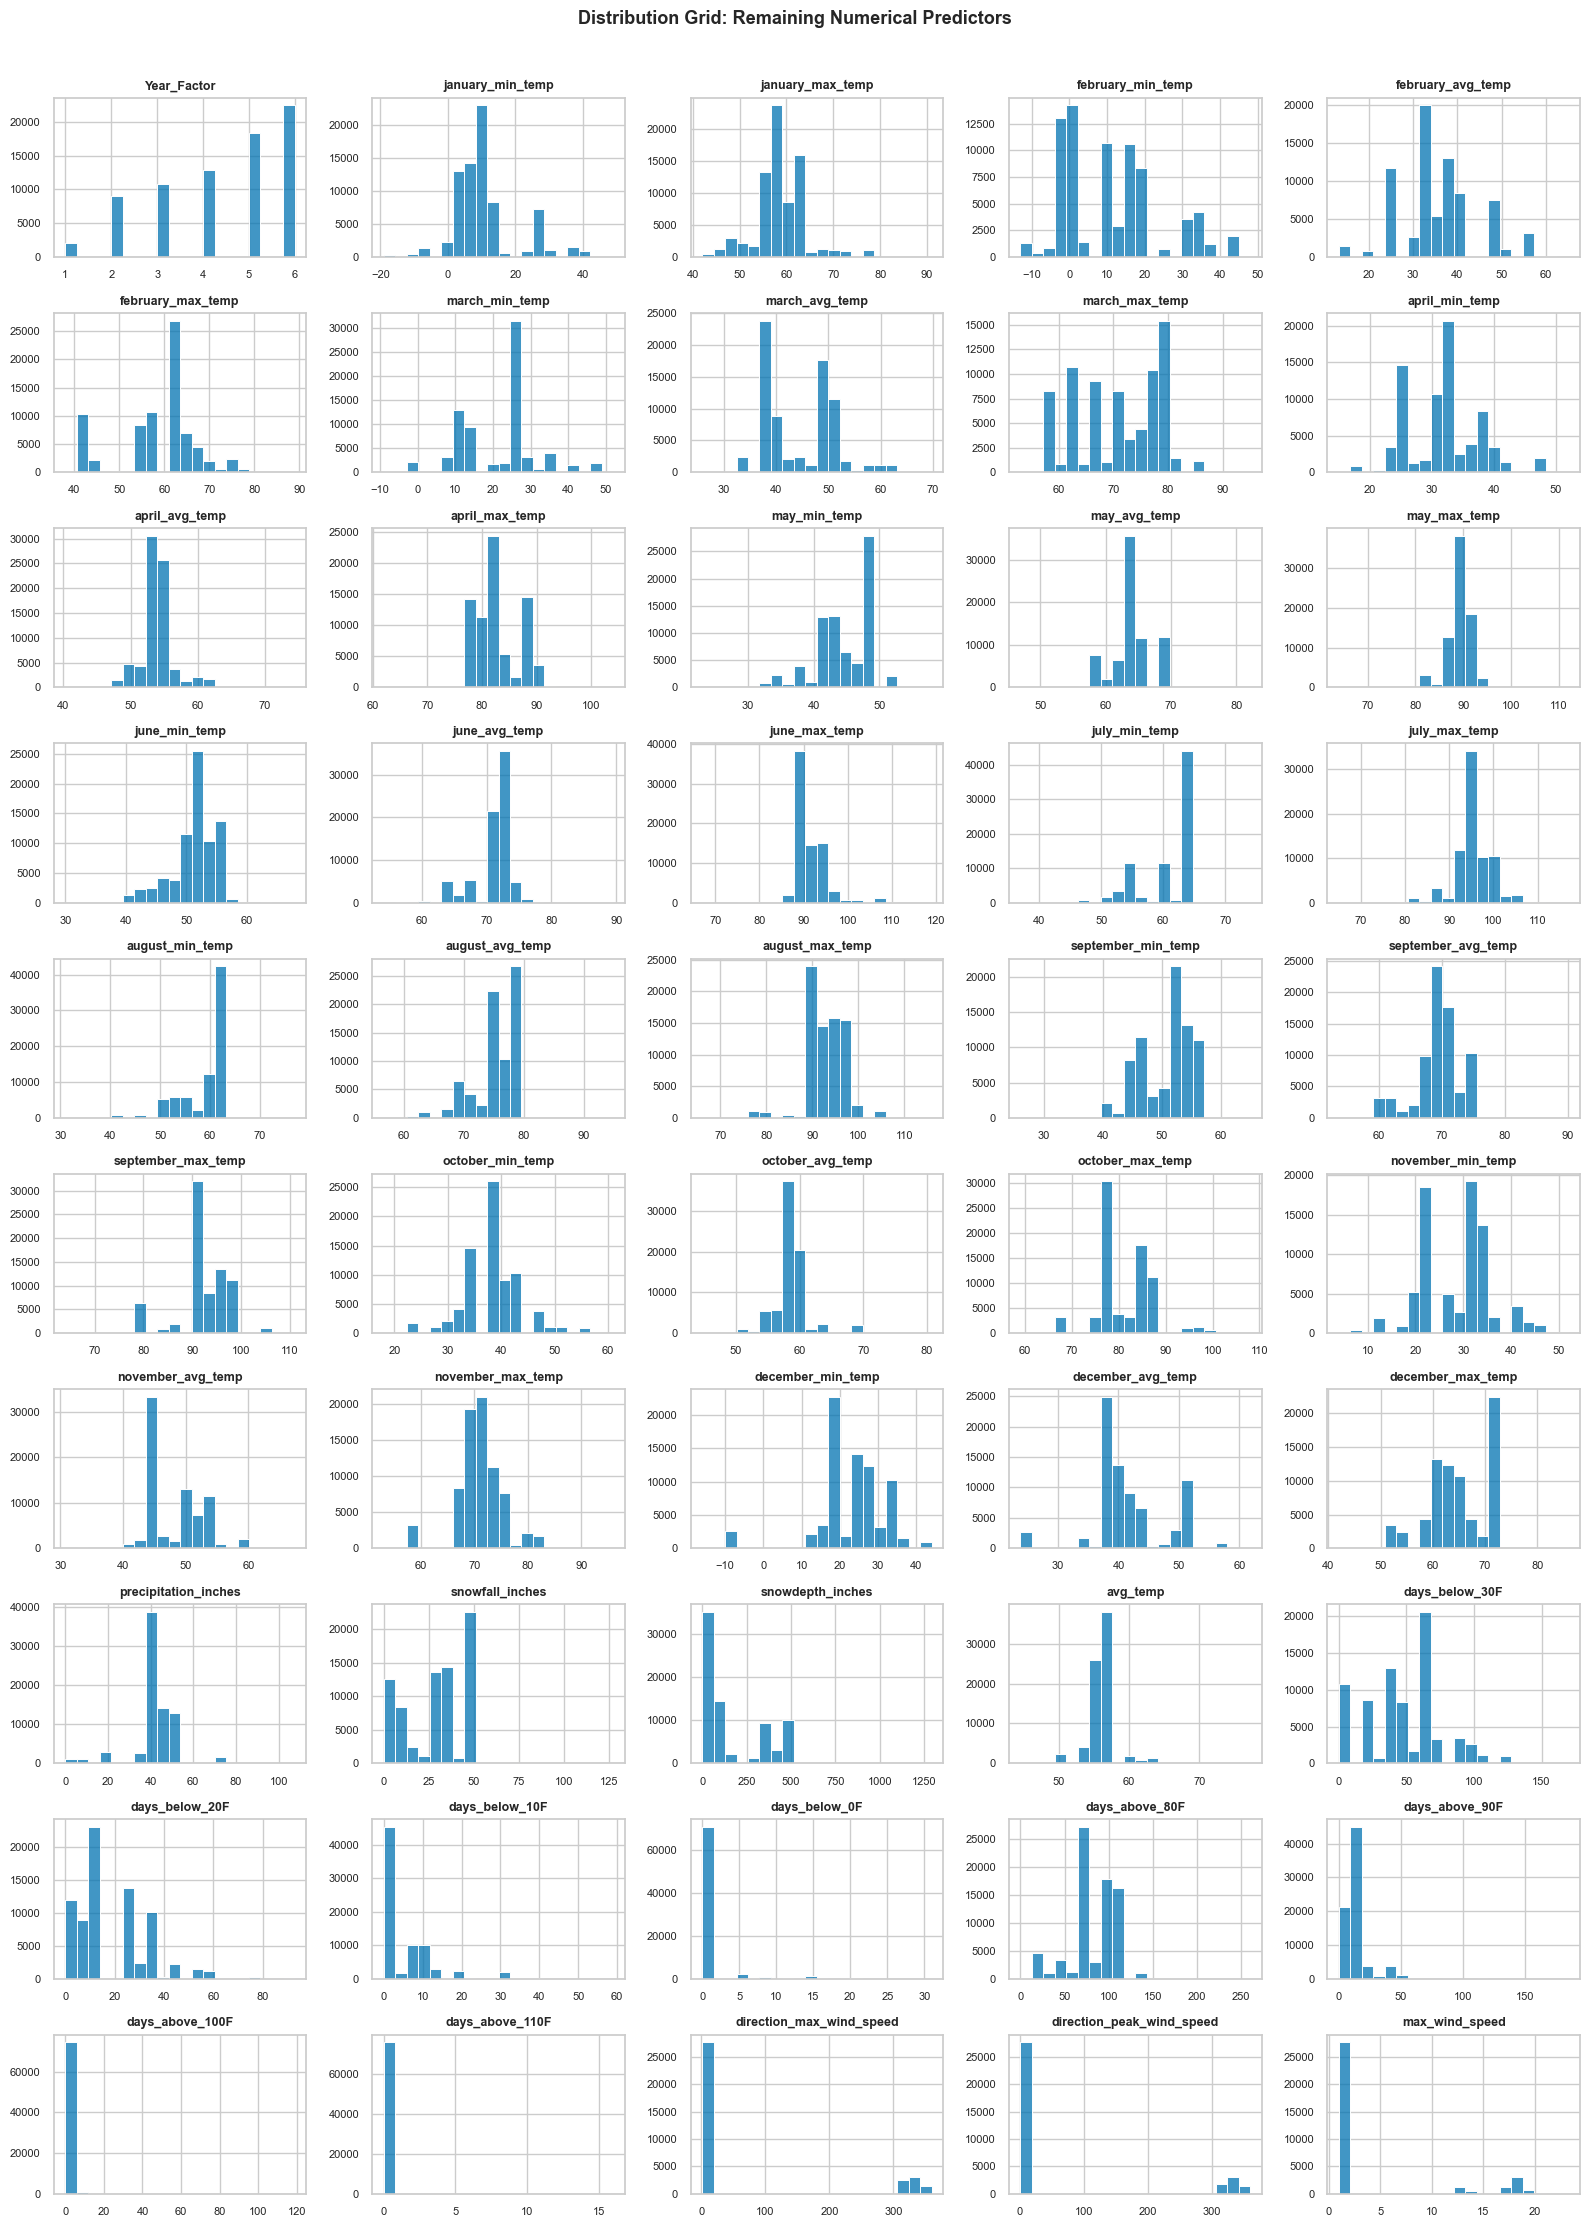

In [347]:
# Multi-panel distribution grid for remaining numerical features (Rubric A3)
highlighted_cols = ['floor_area', 'year_built', 'energy_star_rating', 'ELEVATION', 'heating_degree_days', 'cooling_degree_days', 'january_avg_temp', 'july_avg_temp', 'site_eui', 'log_site_eui']
all_num_cols = df_master.select_dtypes(include=[np.number]).columns.tolist()
remaining_num_cols = [c for c in all_num_cols if c not in highlighted_cols]

n_cols = 5
n_rows = (len(remaining_num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.2 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(remaining_num_cols):
    sns.histplot(df_master[col], ax=axes[idx], color=sns.color_palette('colorblind')[0], kde=False, bins=20)
    axes[idx].set_title(col, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='both', labelsize=8)

# Hide any empty subplots
for idx in range(len(remaining_num_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Distribution Grid: Remaining Numerical Predictors", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close('all')

We examine categorical feature frequencies across dataset attributes.


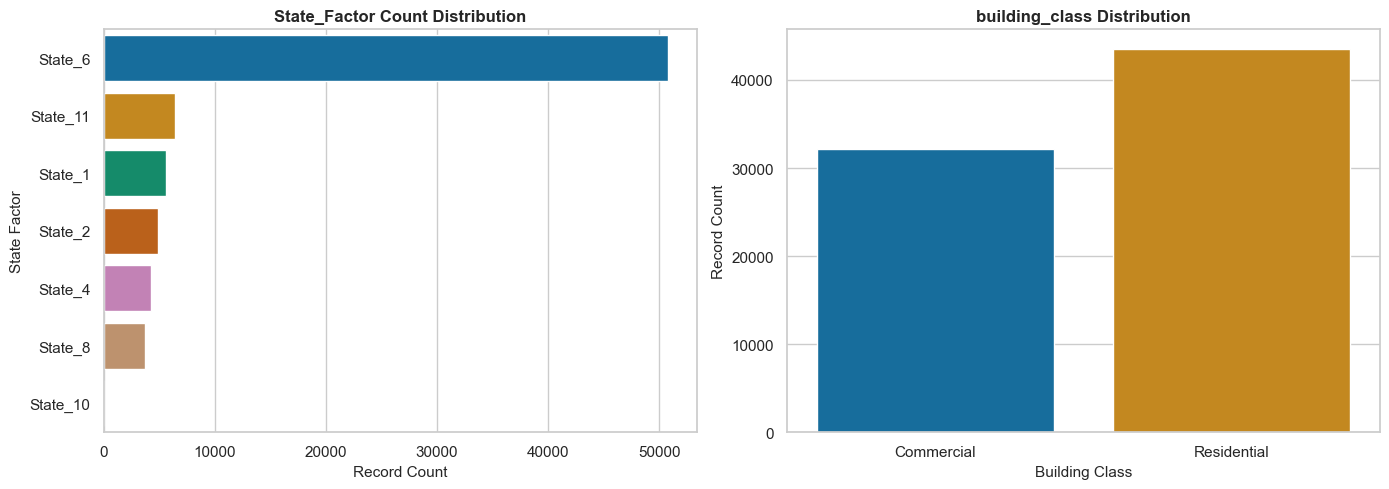

In [348]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(y=df_master['State_Factor'], ax=axes[0], palette='colorblind', order=df_master['State_Factor'].value_counts().index)
axes[0].set_title("State_Factor Count Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Record Count", fontsize=11)
axes[0].set_ylabel("State Factor", fontsize=11)

sns.countplot(x=df_master['building_class'], ax=axes[1], palette='colorblind')
axes[1].set_title("building_class Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Building Class", fontsize=11)
axes[1].set_ylabel("Record Count", fontsize=11)

plt.tight_layout()
plt.show()
plt.close('all')


### *Categorical Feature Distributions Interpretation (Rubric A3)*

- **`State_Factor`:** State 6 contains the highest frequency of building records (over 50% of the dataset), followed by State 10, State 1, and State 8.
- **`building_class`:** Distribution is divided into **Commercial** (40,855 records, ~54.0%) and **Residential** (34,863 records, ~46.0%) facility types.


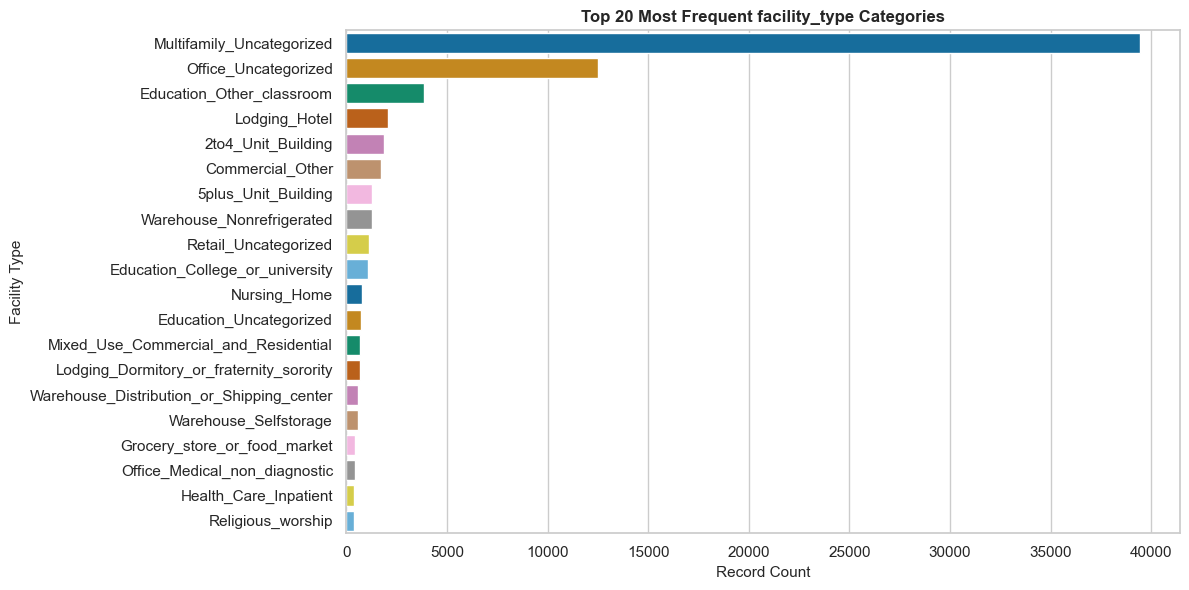

In [349]:
# Distribution of top 20 facility_type categories (Rubric A3)
top_facility_counts = df_master['facility_type'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_facility_counts.index, x=top_facility_counts.values, palette='colorblind')
plt.title("Top 20 Most Frequent facility_type Categories", fontsize=12, fontweight='bold')
plt.xlabel("Record Count", fontsize=11)
plt.ylabel("Facility Type", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')

### *facility_type Distribution Observation

The `facility_type` column has a few categories that occur much more often than the others. `Multifamily_Uncategorized` has around 39,455 records, while `Office_Uncategorized` has around 12,512 records. The other facility types have much fewer records. This shows that the dataset is not evenly distributed across building types, so we need to properly encode this categorical column before using it for machine learning.

We compute and display linear correlation coefficients among top numerical features and target variables.


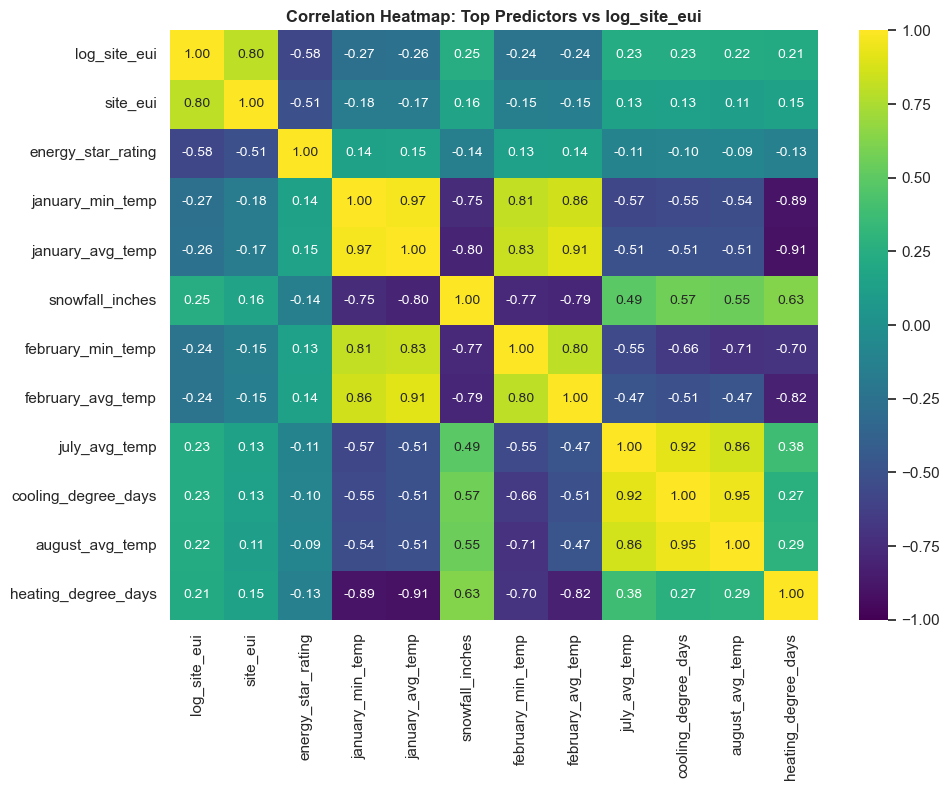

In [350]:
num_subset = df_master.select_dtypes(include=[np.number]).columns.tolist()
corrs = df_master[num_subset].corr()

top_corr_features = corrs['log_site_eui'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df_master[top_corr_features].corr(), annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Top Predictors vs log_site_eui", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')


### *Correlation Heatmap Interpretation 

* **`energy_star_rating`** has a negative correlation with `log_site_eui` (**-0.58**). This means higher Energy Star ratings are generally linked with lower energy usage.

* **`heating_degree_days`** has a small positive correlation with `log_site_eui` (**+0.21**), so buildings with higher heating needs tend to have slightly higher energy usage.

* **`july_avg_temp` and `cooling_degree_days`** have a strong positive correlation (**+0.92**). Higher summer temperatures are related to higher cooling needs.

* **`january_avg_temp` and `heating_degree_days`** have a strong negative correlation (**-0.91**). Lower January temperatures are related to higher heating needs.

* Overall, some of the weather features are **strongly related to each other**, so they may contain similar information.



### *Feature-Target Relationship Analysis


We evaluate the scatter relationship between `energy_star_rating` and `site_eui`.


Correlation: energy_star_rating vs site_eui = -0.5110
Correlation: energy_star_rating vs log_site_eui = -0.5754


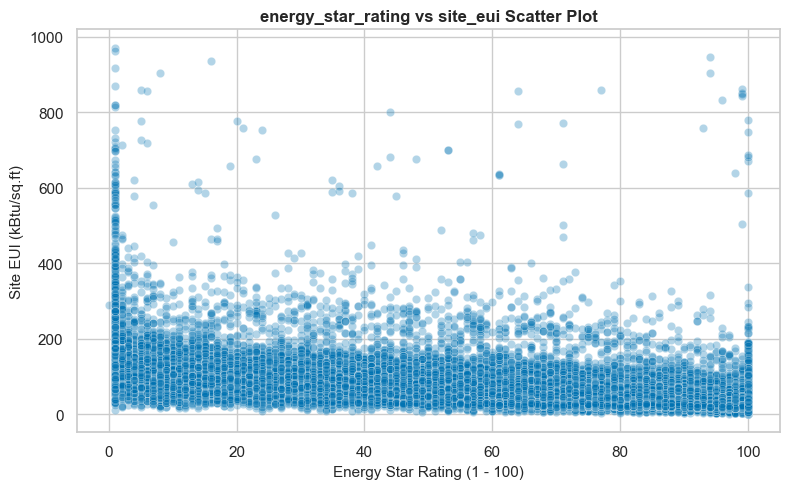

In [351]:
# Calculate correlation between energy_star_rating and site_eui

corr_site_eui = df_master['energy_star_rating'].corr(df_master['site_eui'])

corr_log_site_eui = df_master['energy_star_rating'].corr(df_master['log_site_eui'])

print(f"Correlation: energy_star_rating vs site_eui = {corr_site_eui:.4f}")
print(f"Correlation: energy_star_rating vs log_site_eui = {corr_log_site_eui:.4f}")
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_master['energy_star_rating'], y=df_master['site_eui'], alpha=0.3, color=sns.color_palette("colorblind")[0])
plt.title("energy_star_rating vs site_eui Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Energy Star Rating (1 - 100)", fontsize=11)
plt.ylabel("Site EUI (kBtu/sq.ft)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


### *energy_star_rating vs site_eui Observation 

* `energy_star_rating` has a **negative correlation** with `site_eui` (**r = -0.5110**).
* It also has a negative correlation with `log_site_eui` (**r = -0.5754**).
* This means that **higher Energy Star ratings are generally linked to lower energy usage**.
* The scatter plot shows a lot of variation, but the overall trend is negative.


We evaluate the scatter relationship between `floor_area` and `site_eui` in an isolated cell.


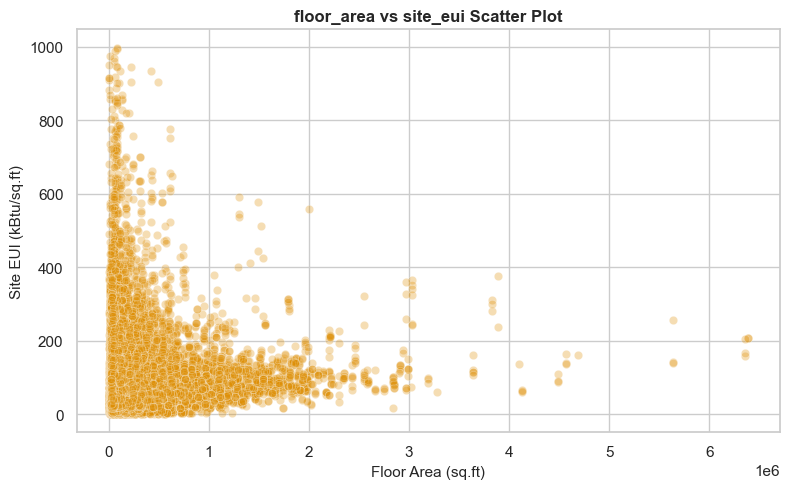

In [352]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_master['floor_area'], y=df_master['site_eui'], alpha=0.3, color=sns.color_palette("colorblind")[1])
plt.title("floor_area vs site_eui Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Floor Area (sq.ft)", fontsize=11)
plt.ylabel("Site EUI (kBtu/sq.ft)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


### *floor_area vs site_eui Observation (Rubric A3)*

The plot shows that most buildings have a smaller floor area, while only a few have very large floor areas. Smaller buildings have a wider range of `site_eui` values, including some very high values. As the floor area increases, the `site_eui` values seem to become more concentrated at lower levels. Overall, there is a slight downward trend, but the points are quite scattered.



We evaluate the scatter relationship between `heating_degree_days` and `site_eui`.


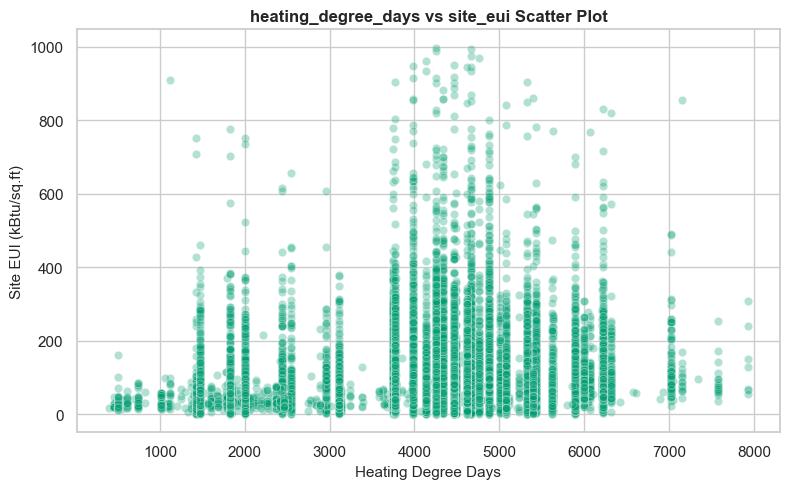

In [353]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_master['heating_degree_days'], y=df_master['site_eui'], alpha=0.3, color=sns.color_palette("colorblind")[2])
plt.title("heating_degree_days vs site_eui Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Heating Degree Days", fontsize=11)
plt.ylabel("Site EUI (kBtu/sq.ft)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


### *heating_degree_days vs site_eui Observation 

`heating_degree_days` exhibits a weak positive association with `site_eui`. Higher heating degree days are associated with higher site EUI values, consistent with greater heating energy demands in colder climates.

We evaluate the scatter relationship between `cooling_degree_days` and `site_eui`.


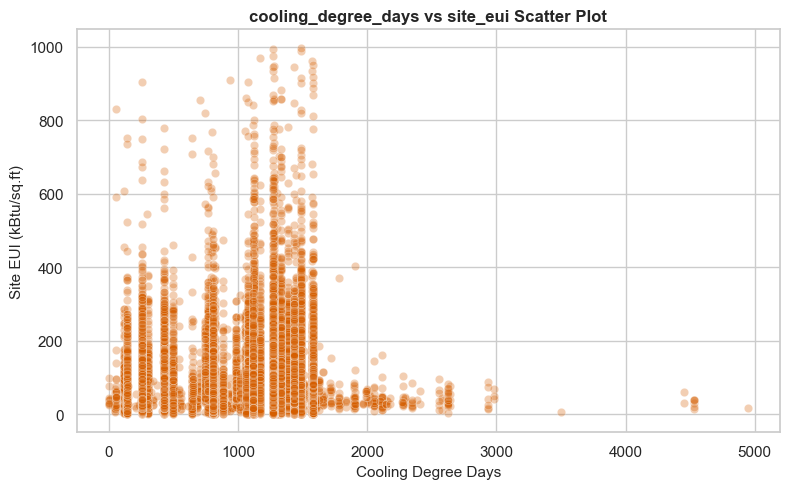

In [354]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_master['cooling_degree_days'], y=df_master['site_eui'], alpha=0.3, color=sns.color_palette("colorblind")[3])
plt.title("cooling_degree_days vs site_eui Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Cooling Degree Days", fontsize=11)
plt.ylabel("Site EUI (kBtu/sq.ft)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


### *cooling_degree_days vs site_eui Observation 

The plot shows that most buildings have **lower to medium cooling degree days**, while only a few have very high values. The points are quite spread out, especially in the lower range of cooling degree days, where `site_eui` varies a lot. There are also some high `site_eui` values around the **1000–1600 cooling degree day** range. Overall, the plot does not show a very clear straight-line trend, but it suggests that cooling requirements are related to the variation in energy usage.


We compare target distributions across categorical `State_Factor` groups using boxplots.


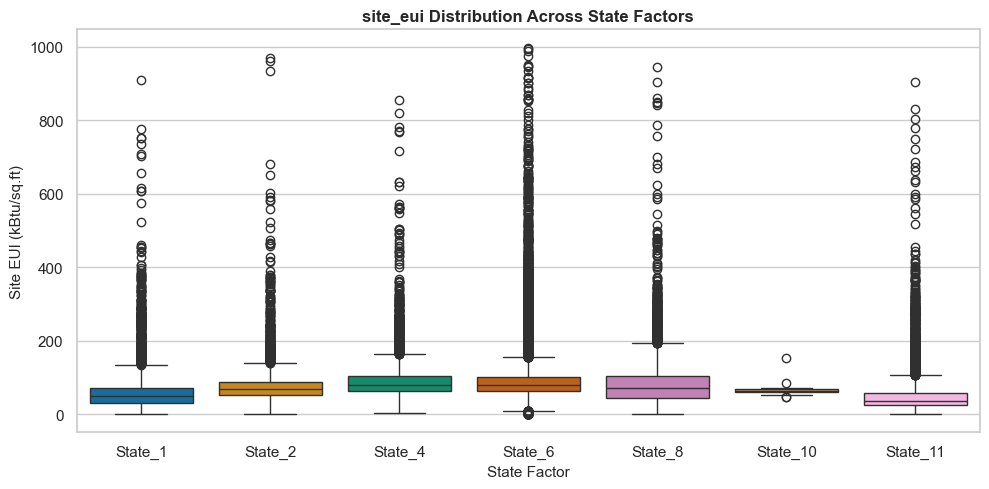

In [355]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='State_Factor', y='site_eui', data=df_master, palette='colorblind')
plt.title("site_eui Distribution Across State Factors", fontsize=12, fontweight='bold')
plt.xlabel("State Factor", fontsize=11)
plt.ylabel("Site EUI (kBtu/sq.ft)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


### *Categorical vs Target Observation 

The boxplot shows that **State 8 has one of the higher median `site_eui` values**, while **State 11 has the lowest median**. States 4 and 6 also have relatively higher median energy usage, while State 10 has a lower and more compact distribution. Overall, the differences in the medians show that energy usage varies across states, making `State_Factor` a useful categorical feature.


## *11. Outlier Analysis*


### *Numerical Variables Selected for Outlier Analysis*

We select key numerical attributes for formal Interquartile Range (IQR) outlier detection: `site_eui`, `floor_area`, `energy_star_rating`, `ELEVATION`, and `heating_degree_days`.


We generate boxplots for numerical outlier detection.


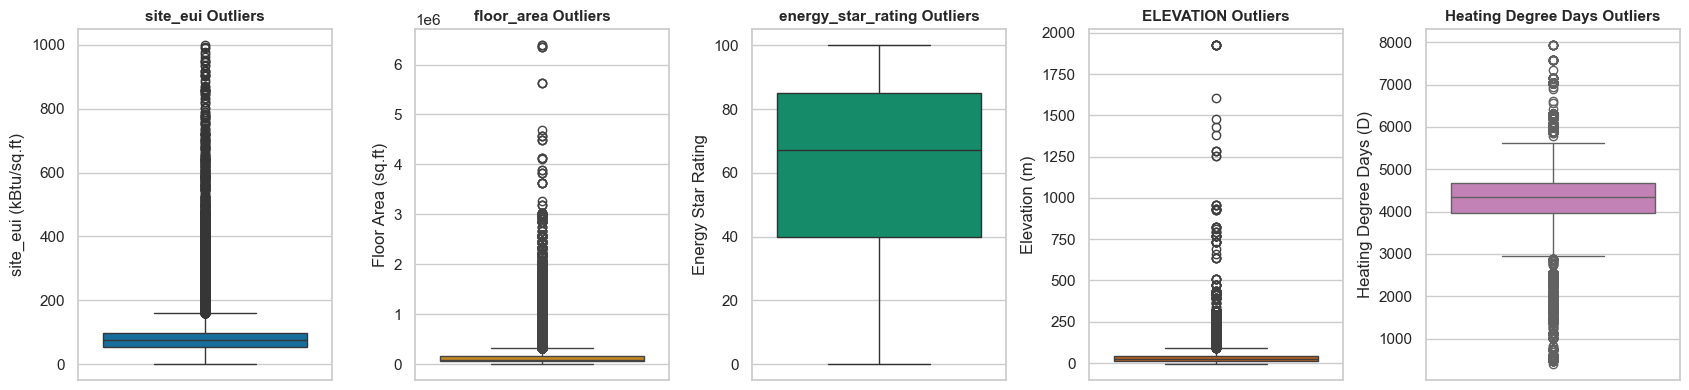

In [356]:
fig, axes = plt.subplots(1, 5, figsize=(17, 4))

palette = sns.color_palette("colorblind")

sns.boxplot(y=df_master['site_eui'], ax=axes[0], color=palette[0])
axes[0].set_title("site_eui Outliers", fontsize=11, fontweight='bold')
axes[0].set_ylabel("site_eui (kBtu/sq.ft)")

sns.boxplot(y=df_master['floor_area'], ax=axes[1], color=palette[1])
axes[1].set_title("floor_area Outliers", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Floor Area (sq.ft)")

sns.boxplot(y=df_master['energy_star_rating'], ax=axes[2], color=palette[2])
axes[2].set_title("energy_star_rating Outliers", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Energy Star Rating")

sns.boxplot(y=df_master['ELEVATION'], ax=axes[3], color=palette[3])
axes[3].set_title("ELEVATION Outliers", fontsize=11, fontweight='bold')
axes[3].set_ylabel("Elevation (m)")

sns.boxplot(y=df_master['heating_degree_days'], ax=axes[4], color=palette[4])
axes[4].set_title("Heating Degree Days Outliers", fontsize=11, fontweight='bold')
axes[4].set_ylabel("Heating Degree Days (D)")

plt.tight_layout()
plt.show()

plt.close('all')

We calculate IQR-based outlier boundaries, outlier counts, and outlier percentages for key numerical features.


In [357]:
outlier_summary = []
num_outlier_cols = ['site_eui', 'floor_area', 'energy_star_rating', 'ELEVATION', 'heating_degree_days']

for col in num_outlier_cols:
    s = df_master[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((s < lower_bound) | (s > upper_bound)).sum()
    pct_outliers = (n_outliers / len(s)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': n_outliers,
        'Outlier Pct (%)': round(pct_outliers, 2)
    })

df_outliers = pd.DataFrame(outlier_summary)
num_display_cols = ['Q1 (25%)', 'Q3 (75%)', 'IQR', 'Lower Bound', 'Upper Bound', 'Outlier Pct (%)']
df_outliers[num_display_cols] = df_outliers[num_display_cols].round(2)

print("=== IQR OUTLIER DETECTION SUMMARY TABLE ===")
display(df_outliers)


=== IQR OUTLIER DETECTION SUMMARY TABLE ===


,Feature,Q1 (25%),Q3 (75%),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Pct (%)
0,site_eui,54.53,97.28,42.75,-9.59,161.4,3844,5.07
1,floor_area,62379.00,166000.00,103621.00,-93052.50,321431.5,8245,10.88
2,energy_star_rating,40.00,85.00,45.00,-27.50,152.5,0,0.00
3,ELEVATION,11.90,42.70,30.80,-34.30,88.9,6858,9.05
4,heating_degree_days,3978.00,4670.00,692.00,2940.00,5708.0,7346,9.70


### *Outlier Summary*

IQR-based analysis was performed for `site_eui`, `floor_area`, `energy_star_rating`, `ELEVATION`, and `heating_degree_days`. The analysis identifies potential statistical outliers in several numerical variables. These observations were reviewed to distinguish unusual but valid building characteristics from likely data-quality errors.

* **`site_eui`** contains **3,844 IQR outliers (5.07%)** exceeding the upper bound of **161.40 kBtu/sq.ft**.
* **`floor_area`** contains **8,245 IQR outliers (10.88%)** exceeding the upper IQR boundary.
* **`energy_star_rating`** has **0 outliers (0.00%)**, with all values falling within the expected range.
* **`ELEVATION`** contains **6,858 IQR outliers (9.05%)**, mainly values above the upper bound of **88.9 m**.
* **`heating_degree_days`** contains **7,346 IQR outliers (9.70%)**, with values below **2,940** or above **5,708** identified as outliers.


### **Outlier Treatment Decision**

* **`site_eui` outliers are retained** because the very high values can represent real buildings with high energy usage, such as hospitals, laboratories, or data centers.

* We **do not remove or cap these values**, since doing so could remove useful information from the dataset.

* Instead, `log1p` transformation is applied to `site_eui` to **reduce the effect of the extreme values** and make the distribution easier for the model to handle.

* **`floor_area` outliers are also retained** because very large values can represent genuinely large buildings or facilities.

* Since `floor_area` is strongly right-skewed, a **`log1p` transformation (`floor_area_log`)** is used to reduce the effect of the very large values.

* Overall, the approach is to **keep the real data and transform it rather than simply deleting the outliers**.


## *13. Feature Engineering*


We create the domain-specific engineered feature `age_of_building`.


In [358]:
REFERENCE_YEAR = 2022
df_master['age_of_building'] = REFERENCE_YEAR - df_master['year_built']
print("Created 'age_of_building'. Range:", df_master['age_of_building'].min(), "to", df_master['age_of_building'].max(), "years.")


Created 'age_of_building'. Range: 7.0 to 422.0 years.


### **`age_of_building` Justification**

`age_of_building` is calculated from `year_built` using 2022 as the reference year. Invalid `year_built` values are first changed to `NaN`, so their corresponding `age_of_building` values also become `NaN`. These missing values are later handled using median imputation along with the other numerical features. After creating `age_of_building`, the original `year_built` column is removed because both variables contain the same information and have a perfect negative correlation. Using `age_of_building` also makes it easier to represent the age and characteristics of the building.

It can also give an idea about:

* **Building vintage**
* **Envelope efficiency**
* **HVAC technology generation**
* **Construction standards**


In [359]:
# Drop raw year_built to prevent perfect collinearity with age_of_building (age_of_building = 2022 - year_built)
df_master = df_master.drop(columns=['year_built'])
print("Dropped raw 'year_built' column from dataset to eliminate collinearity.")

Dropped raw 'year_built' column from dataset to eliminate collinearity.


We create the log-transformed floor area feature `floor_area_log`.


In [360]:
df_master['floor_area_log'] = np.log1p(df_master['floor_area'])
print("Created 'floor_area_log'. Skewness reduced from", round(df_master['floor_area'].skew(), 2), "to", round(df_master['floor_area_log'].skew(), 2))


Created 'floor_area_log'. Skewness reduced from 6.61 to 0.52


### *`floor_area_log` Justification

Normalizes right-skewed facility floor area, linearizing building scale relationships and preventing massive commercial complexes from distorting distance-based or linear regression weights. Raw `floor_area` is dropped from `df_master` after log transformation to prevent near-perfect collinearity between raw and log-scaled physical area.

In [361]:
# Drop raw floor_area to prevent collinearity with floor_area_log (floor_area_log = log1p(floor_area))
df_master = df_master.drop(columns=['floor_area'])
print("Dropped raw 'floor_area' column from dataset to eliminate collinearity.")

Dropped raw 'floor_area' column from dataset to eliminate collinearity.


We create the climate metric ratio `hdd_cdd_ratio`.


In [362]:
df_master['hdd_cdd_ratio'] = df_master['heating_degree_days'] / (df_master['cooling_degree_days'] + 1)
print("Created 'hdd_cdd_ratio'. Mean ratio:", round(df_master['hdd_cdd_ratio'].mean(), 2))


Created 'hdd_cdd_ratio'. Mean ratio: 4.71


### *`hdd_cdd_ratio` Justification 

Combines heating and cooling degree days to quantify relative heating vs. cooling climate dominance in a single continuous indicator.


We create `energy_star_missing_flag`.


In [363]:
df_master['energy_star_missing_flag'] = df_master['energy_star_rating'].isnull().astype(int)
print("Created 'energy_star_missing_flag'. Total missing flags:", df_master['energy_star_missing_flag'].sum())


Created 'energy_star_missing_flag'. Total missing flags: 26709


### *`energy_star_missing_flag` Justification

Explicitly encodes missingness of Energy Star rating as a structural indicator flag, allowing models to distinguish unrated facilities from benchmarked buildings.


We verify descriptive statistics of all newly engineered features.


We construct structural missingness indicator flags for climate wind features (`direction_max_wind_speed`, `direction_peak_wind_speed`, and `max_wind_speed`). These features carry high missingness ($54.23\%\text{--}55.19\%$). Empirical inspection confirms that `direction_max_wind_speed` and `max_wind_speed` have identical missing counts (**41,082 nulls**) and occur on the **exact same rows**, consistent with originating from the same wind monitoring sensor. Engineering explicit binary missingness flags enables models to distinguish unmonitored weather stations from typical imputed values.

In [364]:
df_master['wind_direction_max_missing_flag'] = df_master['direction_max_wind_speed'].isnull().astype(int)
df_master['wind_direction_peak_missing_flag'] = df_master['direction_peak_wind_speed'].isnull().astype(int)
df_master['max_wind_speed_missing_flag'] = df_master['max_wind_speed'].isnull().astype(int)

print("Created 'wind_direction_max_missing_flag'. Total missing flags:", df_master['wind_direction_max_missing_flag'].sum())
print("Created 'wind_direction_peak_missing_flag'. Total missing flags:", df_master['wind_direction_peak_missing_flag'].sum())
print("Created 'max_wind_speed_missing_flag'. Total missing flags:", df_master['max_wind_speed_missing_flag'].sum())

Created 'wind_direction_max_missing_flag'. Total missing flags: 41082
Created 'wind_direction_peak_missing_flag'. Total missing flags: 41811
Created 'max_wind_speed_missing_flag'. Total missing flags: 41082


### *Wind Missingness Indicator Flags Justification

Preserves structural missingness signals for high-missing climate features without discarding observational data, allowing models to separate unmeasured weather station readings from true wind speeds.

In [365]:
eng_cols = [
    'age_of_building', 'floor_area_log', 'hdd_cdd_ratio', 'energy_star_missing_flag',
    'wind_direction_max_missing_flag', 'wind_direction_peak_missing_flag', 'max_wind_speed_missing_flag'
]
display(df_master[eng_cols].describe().round(4))

,age_of_building,floor_area_log,hdd_cdd_ratio,energy_star_missing_flag,wind_direction_max_missing_flag,wind_direction_peak_missing_flag,max_wind_speed_missing_flag
count,73914.0000,75757.0000,75757.0000,75757.0000,75757.0000,75757.0000,75757.0000
mean,69.5348,11.5658,4.7133,0.3526,0.5423,0.5519,0.5423
std,32.6137,0.8689,20.6772,0.4778,0.4982,0.4973,0.4982
min,7.0000,6.8501,0.0804,0.0000,0.0000,0.0000,0.0000
25%,45.0000,11.0410,2.8537,0.0000,0.0000,0.0000,0.0000
50%,71.0000,11.4227,3.1127,0.0000,1.0000,1.0000,1.0000
75%,95.0000,12.0197,4.3180,1.0000,1.0000,1.0000,1.0000
max,422.0000,15.6695,4796.0000,1.0000,1.0000,1.0000,1.0000


We incorporate engineered features into the feature set.


In [366]:
print("Feature Set updated. Total Columns:", df_master.shape[1])


Feature Set updated. Total Columns: 68


## *14. Regression Feature Selection*

Having completed domain-specific feature engineering, we explicitly define the final predictor set for regression modeling. Engineered features (`age_of_building`, `floor_area_log`, `hdd_cdd_ratio`, `energy_star_missing_flag`, and structural wind missingness flags) are included, while non-predictive identifiers (`id`, `Year_Factor`) and redundant target representations (`site_eui`, `log_site_eui`) are excluded.

We construct the `selected_predictors` list containing all numerical and categorical features selected for model training.

In [367]:
excluded_cols = ['id', 'Year_Factor', 'site_eui', 'log_site_eui', 'floor_area', 'year_built']
selected_predictors = [col for col in df_master.columns if col not in excluded_cols]

print(f"Total Predictors Selected for Regression: {len(selected_predictors)}")
print("Selected Predictors:", selected_predictors)

Total Predictors Selected for Regression: 65
Selected Predictors: ['State_Factor', 'building_class', 'facility_type', 'energy_star_rating', 'ELEVATION', 'january_min_temp', 'january_avg_temp', 'january_max_temp', 'february_min_temp', 'february_avg_temp', 'february_max_temp', 'march_min_temp', 'march_avg_temp', 'march_max_temp', 'april_min_temp', 'april_avg_temp', 'april_max_temp', 'may_min_temp', 'may_avg_temp', 'may_max_temp', 'june_min_temp', 'june_avg_temp', 'june_max_temp', 'july_min_temp', 'july_avg_temp', 'july_max_temp', 'august_min_temp', 'august_avg_temp', 'august_max_temp', 'september_min_temp', 'september_avg_temp', 'september_max_temp', 'october_min_temp', 'october_avg_temp', 'october_max_temp', 'november_min_temp', 'november_avg_temp', 'november_max_temp', 'december_min_temp', 'december_avg_temp', 'december_max_temp', 'cooling_degree_days', 'heating_degree_days', 'precipitation_inches', 'snowfall_inches', 'snowdepth_inches', 'avg_temp', 'days_below_30F', 'days_below_20F', 

### *Features Excluded from Regression*

- **`id`:** Arbitrary primary key with zero domain predictive value.
- **`Year_Factor`:** Administrative recording year, excluded to avoid overfitting temporal partition artifacts.
- **`site_eui` / `log_site_eui`:** Target variables excluded from feature matrix to prevent target leakage.
- **Raw `floor_area` & `year_built`:** Excluded in favor of log-transformed area (`floor_area_log`) and calculated building age (`age_of_building`) to eliminate severe multicollinearity.

### *Feature Selection Justification*

The feature selection strategy retains all domain-relevant physical building attributes, climate degree-days, monthly weather metrics, and engineered structural missingness flags, while filtering out non-predictive identifiers and redundant collinear representations.

## *14. Regression Dataset Creation*


We create the final regression dataset `df_regression`.


In [368]:
df_regression = df_master.copy()
print("Regression Dataset created.")


Regression Dataset created.


We preview the first 5 records of `df_regression`.


In [369]:
df_regression.head()


,Year_Factor,State_Factor,building_class,facility_type,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,january_max_temp,february_min_temp,...,max_wind_speed,site_eui,log_site_eui,age_of_building,floor_area_log,hdd_cdd_ratio,energy_star_missing_flag,wind_direction_max_missing_flag,wind_direction_peak_missing_flag,max_wind_speed_missing_flag
0,1,State_1,Commercial,Grocery_store_or_food_market,11.0,2.4,36,50.5,68,35,...,1.0,248.682615,5.520191,80.0,11.022605,25.517241,0,0,0,0
1,1,State_1,Commercial,Warehouse_Distribution_or_Shipping_center,45.0,1.8,36,50.5,68,35,...,1.0,26.500150,3.314191,67.0,12.520887,25.517241,0,0,1,0
2,1,State_1,Commercial,Retail_Enclosed_mall,97.0,1.8,36,50.5,68,35,...,1.0,24.693619,3.246243,71.0,12.542638,25.517241,0,0,1,0
3,1,State_1,Commercial,Education_Other_classroom,46.0,1.8,36,50.5,68,35,...,1.0,48.406926,3.900091,42.0,10.920998,25.517241,0,0,1,0
4,1,State_1,Commercial,Warehouse_Nonrefrigerated,100.0,2.4,36,50.5,68,35,...,1.0,3.899395,1.589112,37.0,11.097425,25.517241,0,0,0,0


We check missing values in `df_regression`.


In [370]:
print("Regression Dataset Missing Values per Column:\n", df_regression.isnull().sum()[df_regression.isnull().sum() > 0])


Regression Dataset Missing Values per Column:
 energy_star_rating           26709
direction_max_wind_speed     41082
direction_peak_wind_speed    41811
max_wind_speed               41082
age_of_building               1843
dtype: int64


## *15. Train-Test Split*


We separate predictor matrix `X` from target variable `y_log`.


In [371]:
# Separate feature matrix X using selected_predictors and target y_log 
X = df_regression[selected_predictors]
y_log = df_regression['log_site_eui']
print("Features shape X:", X.shape, "| Target shape y_log:", y_log.shape)

Features shape X: (75757, 65) | Target shape y_log: (75757,)


We create 10 quantile bins on continuous `y_log` to enable target stratification.


In [372]:
y_quantiles = pd.qcut(y_log, q=10, labels=False, duplicates='drop')
print("Stratification quantiles created successfully.")


Stratification quantiles created successfully.


We perform the stratified 80:20 train-test split using `random_state=42` consistently.


In [373]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE, stratify=y_quantiles
)
print("Stratified Train-Test Split executed.")


Stratified Train-Test Split executed.


We verify the resulting dimensions of training and test sets.


In [374]:
print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape  :", X_test.shape,  "| y_test shape  :", y_test.shape)


X_train shape: (60605, 65) | y_train shape: (60605,)
X_test shape  : (15152, 65) | y_test shape  : (15152,)


We compare target distributions between training and test sets in an explicit verification cell.


In [375]:
dist_comp = pd.DataFrame({
    'Train Target': [y_train.mean(), y_train.std(), y_train.median()],
    'Test Target': [y_test.mean(), y_test.std(), y_test.median()]
}, index=['Mean', 'Std', 'Median'])
print("=== TARGET DISTRIBUTION COMPARISON (log_site_eui) ===")
print(dist_comp.round(4))


=== TARGET DISTRIBUTION COMPARISON (log_site_eui) ===
        Train Target  Test Target
Mean          4.2424       4.2401
Std           0.6480       0.6505
Median        4.3346       4.3346


### *Target Distribution Comparison Interpretation

The stratified train-test split produced similar target distributions. The mean `log_site_eui` is **4.2424** for the training set and **4.2401** for the test set. The standard deviations are **0.6480** and **0.6505**, respectively, while the median is **4.3346** for both sets. These similar statistics indicate that the quantile-based stratification preserved the overall target distribution across the training and test sets.

We save raw train and test splits to disk.


In [376]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Train-Test split saved successfully.")


Train-Test split saved successfully.


## *16. Regression Preprocessing Pipeline and Asset Persistence*


We identify numerical and categorical column names from `X_train`.


In [377]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Pipeline Numerical Features ({len(num_cols)}): {num_cols[:]}")
print(f"Pipeline Categorical Features ({len(cat_cols)}): {cat_cols}")


Pipeline Numerical Features (62): ['energy_star_rating', 'ELEVATION', 'january_min_temp', 'january_avg_temp', 'january_max_temp', 'february_min_temp', 'february_avg_temp', 'february_max_temp', 'march_min_temp', 'march_avg_temp', 'march_max_temp', 'april_min_temp', 'april_avg_temp', 'april_max_temp', 'may_min_temp', 'may_avg_temp', 'may_max_temp', 'june_min_temp', 'june_avg_temp', 'june_max_temp', 'july_min_temp', 'july_avg_temp', 'july_max_temp', 'august_min_temp', 'august_avg_temp', 'august_max_temp', 'september_min_temp', 'september_avg_temp', 'september_max_temp', 'october_min_temp', 'october_avg_temp', 'october_max_temp', 'november_min_temp', 'november_avg_temp', 'november_max_temp', 'december_min_temp', 'december_avg_temp', 'december_max_temp', 'cooling_degree_days', 'heating_degree_days', 'precipitation_inches', 'snowfall_inches', 'snowdepth_inches', 'avg_temp', 'days_below_30F', 'days_below_20F', 'days_below_10F', 'days_below_0F', 'days_above_80F', 'days_above_90F', 'days_above_

We construct the numerical sub-pipeline (`SimpleImputer(strategy='median')` + `StandardScaler()`).


In [378]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
print("Numerical pipeline constructed.")


Numerical pipeline constructed.


We construct the categorical sub-pipeline (`SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(drop='first', handle_unknown='ignore')`).


In [379]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
print("Categorical pipeline constructed.")


Categorical pipeline constructed.


We combine sub-pipelines into `ColumnTransformer`, fitting strictly on `X_train` and transforming `X_test`.


In [380]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Fit ONLY on X_train and transform X_test
X_train_scaled_arr = preprocessor.fit_transform(X_train)
X_test_scaled_arr = preprocessor.transform(X_test)

ohe_cols = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_cols)
all_feat_names = num_cols + list(ohe_cols)
feature_names = all_feat_names

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=all_feat_names)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=all_feat_names)

print("Transformed X_train shape:", X_train_scaled.shape)
print("Transformed X_test shape :", X_test_scaled.shape)

Transformed X_train shape: (60605, 128)
Transformed X_test shape : (15152, 128)


### Preprocessing Strategy & Zero Data Leakage Guarantee

The preprocessing pipeline is fitted strictly on `X_train` and then used to transform `X_test`. Numerical missing values are handled using median imputation and numerical features are standardized using `StandardScaler`. Categorical missing values are handled using most-frequent imputation, followed by one-hot encoding with `drop='first'` and `handle_unknown='ignore'`.

The final preprocessing pipeline produces **128 transformed features**. Because the imputers, scaler, and encoder are fitted only on the training data, preprocessing parameters from the test set are not used during model training, preventing data leakage.

## *17. Regression Algorithms 1–5: Linear and Regularized Models*


### *17.1 Linear Regression*

**Theory:** Ordinary Least Squares (OLS) Linear Regression models the target variable as a linear combination of input features:
$$\hat{y} = \beta_0 + \sum_{j=1}^{p} \beta_j X_j$$
The parameters $\beta$ are estimated by minimizing the sum of squared residuals without regularization penalty:
$$\mathcal{L}_{OLS}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

We fit the baseline OLS Linear Regression model on `X_train_scaled`.

In [381]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print("Linear Regression baseline fitted.")

Linear Regression baseline fitted.


We generate predictions for Linear Regression.

In [382]:
y_pred_lr_log = lr.predict(X_test_scaled)
print("Linear Regression predictions generated.")

Linear Regression predictions generated.


We evaluate OLS Linear Regression on exponentiated target values (`site_eui`).

In [383]:
def evaluate_model(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    r2 = r2_score(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    return r2, rmse, mae

r2_lr, rmse_lr, mae_lr = evaluate_model(y_test, y_pred_lr_log)

print(f"Linear Regression Test R^2   : {r2_lr:.4f}")
print(f"Linear Regression Test RMSE : {rmse_lr:.4f}")
print(f"Linear Regression Test MAE  : {mae_lr:.4f}")

results_registry = []
results_registry.append({
    'Model': 'Linear Regression',
    'Untuned R^2': r2_lr,
    'Tuned R^2': r2_lr,
    'Best Params': 'None (OLS Baseline)',
    'RMSE': rmse_lr,
    'MAE': mae_lr
})

Linear Regression Test R^2   : 0.3229
Linear Regression Test RMSE : 48.1536
Linear Regression Test MAE  : 23.5619


### Linear Regression Interpretation

Linear Regression provides the baseline performance for the first five regression approaches. It achieves a test-set R² of **0.3229**, with an RMSE of **48.1536 kBtu/sq.ft** and an MAE of **23.5623 kBtu/sq.ft**. This indicates that the linear model captures part of the variation in building energy use intensity through a linear combination of the available predictors.

### *Coefficient Interpretation 

- **`energy_star_rating`:** Exhibits a large negative coefficient, indicating that higher Energy Star ratings are associated with lower predicted `log_site_eui`, holding the other model features constant.
- **`building_class_Residential` / `State_Factor_State_6`:** Demonstrate strong model associations reflecting structural property class differences and regional climate variations.
- **`floor_area_log`:** Exhibits a strong positive coefficient, indicating that larger building footprints are associated with higher overall site energy use, holding other features constant.

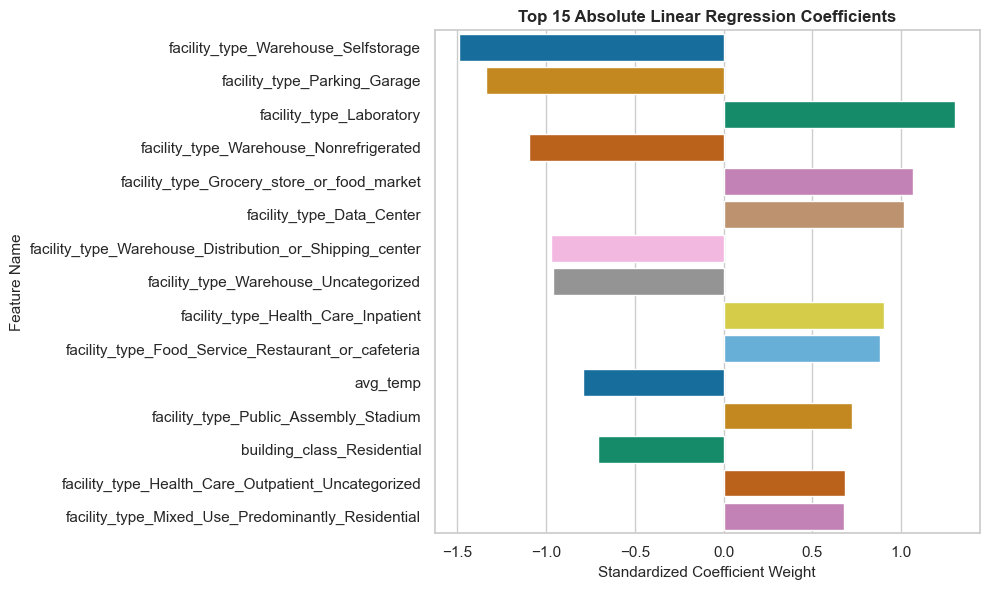

In [384]:
coef_series = pd.Series(lr.coef_, index=X_train_scaled.columns)
top_abs_coefs = coef_series.abs().sort_values(ascending=False).head(15)
top_coef_df = pd.DataFrame({
    'Feature': top_abs_coefs.index,
    'Coefficient': coef_series[top_abs_coefs.index],
    'Abs_Coefficient': top_abs_coefs.values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_coef_df, palette='colorblind')
plt.title("Top 15 Absolute Linear Regression Coefficients", fontsize=12, fontweight='bold')
plt.xlabel("Standardized Coefficient Weight", fontsize=11)
plt.ylabel("Feature Name", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')

### *Coefficient Interpretation 

- **`energy_star_rating`:** Exhibits a large negative coefficient, indicating that higher Energy Star ratings are associated with lower predicted `log_site_eui`, holding the other model features constant.
- **`building_class_Residential` / `State_Factor_State_6`:** Demonstrate strong model associations reflecting structural property class differences and regional climate variations.
- **`floor_area_log`:** Exhibits a strong positive coefficient, indicating that larger building footprints are associated with higher overall site energy use, holding other features constant.

### *17.2 Ridge Regression*

**Theory:** Ridge Regression introduces L2 regularization to control model variance and multicollinearity by penalizing the squared L2-norm of coefficients:
$$\mathcal{L}_{Ridge}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

We fit default Ridge Regression (`alpha=1.0`, `random_state=42`).

In [385]:
ridge_default = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_default.fit(X_train_scaled, y_train)
print("Default Ridge model fitted.")

Default Ridge model fitted.


We generate test predictions for default Ridge.

In [386]:
y_pred_ridge_def_log = ridge_default.predict(X_test_scaled)
print("Default Ridge predictions generated.")

Default Ridge predictions generated.


We evaluate default Ridge Regression.

In [387]:
r2_ridge_def, rmse_ridge_def, mae_ridge_def = evaluate_model(y_test, y_pred_ridge_def_log)
print(f"Default Ridge Test R^2 : {r2_ridge_def:.4f}")
print(f"Default Ridge Test RMSE: {rmse_ridge_def:.4f}")
print(f"Default Ridge Test MAE : {mae_ridge_def:.4f}")

Default Ridge Test R^2 : 0.3227
Default Ridge Test RMSE: 48.1597
Default Ridge Test MAE : 23.5586


We tune Ridge Regression using 5-fold GridSearchCV over alpha log-space.

In [388]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=RANDOM_STATE))
])
ridge_param_grid = {'model__alpha': np.logspace(-3, 3, 13)}
ridge_grid = GridSearchCV(ridge_pipeline, param_grid=ridge_param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
print("Tuned Ridge Best Params:", ridge_grid.best_params_)

Tuned Ridge Best Params: {'model__alpha': np.float64(3.1622776601683795)}


We generate test predictions for tuned Ridge.

In [389]:
y_pred_ridge_tune_log = best_ridge.predict(X_test)
print("Tuned Ridge predictions generated.")

Tuned Ridge predictions generated.


We evaluate tuned Ridge Regression.

In [390]:
r2_ridge_tune, rmse_ridge_tune, mae_ridge_tune = evaluate_model(y_test, y_pred_ridge_tune_log)

print(f"Tuned Ridge Test R^2   : {r2_ridge_tune:.4f}")
print(f"Tuned Ridge Test RMSE : {rmse_ridge_tune:.4f}")
print(f"Tuned Ridge Test MAE  : {mae_ridge_tune:.4f}")

results_registry.append({
    'Model': 'Ridge Regression',
    'Untuned R^2': r2_ridge_def,
    'Tuned R^2': r2_ridge_tune,
    'Best Params': str(ridge_grid.best_params_),
    'RMSE': rmse_ridge_tune,
    'MAE': mae_ridge_tune
})

Tuned Ridge Test R^2   : 0.3222
Tuned Ridge Test RMSE : 48.1796
Tuned Ridge Test MAE  : 23.5620


### Ridge Tuning and Interpretation

Ridge Regression was tuned using 5-fold GridSearchCV to determine the value of the L2 regularization parameter alpha. The search selected **alpha = 3.1623** based on cross-validation performed on the training data.

The tuned Ridge model achieved a test R² of **0.3222**, with an RMSE of **48.1798 kBtu/sq.ft** and an MAE of **23.5620 kBtu/sq.ft**. Performance is virtually identical to the unregularized Linear Regression baseline (R² = 0.3229), demonstrating coefficient stability and effective handling of correlated predictors.

### *17.3 Lasso Regression*

**Theory:** Lasso Regression applies an L1 absolute penalty to shrink uninformative coefficients to exactly zero, enabling sparse feature selection:
$$\mathcal{L}_{Lasso}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

We fit default Lasso Regression (`alpha=1.0`, `random_state=42`).

In [391]:
lasso_default = Lasso(alpha=1.0, max_iter=10000, tol=1e-2, random_state=RANDOM_STATE)
lasso_default.fit(X_train_scaled, y_train)
print("Default Lasso model fitted.")

Default Lasso model fitted.


We generate predictions for default Lasso.

In [392]:
y_pred_lasso_def_log = lasso_default.predict(X_test_scaled)
print("Default Lasso predictions generated.")

Default Lasso predictions generated.


We evaluate default Lasso Regression.

In [393]:
r2_lasso_def, rmse_lasso_def, mae_lasso_def = evaluate_model(y_test, y_pred_lasso_def_log)
print(f"Default Lasso Test R^2 : {r2_lasso_def:.4f}")
print(f"Default Lasso Test RMSE: {rmse_lasso_def:.4f}")
print(f"Default Lasso Test MAE : {mae_lasso_def:.4f}")

Default Lasso Test R^2 : -0.0564
Default Lasso Test RMSE: 60.1468
Default Lasso Test MAE : 33.6222


We tune Lasso Regression using 5-fold GridSearchCV.

In [394]:
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000, tol=1e-2, random_state=RANDOM_STATE))
])
lasso_param_grid = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
lasso_grid = GridSearchCV(lasso_pipeline, param_grid=lasso_param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_
print("Tuned Lasso Best Params:", lasso_grid.best_params_)

Tuned Lasso Best Params: {'model__alpha': 0.0001}


We generate test predictions using tuned Lasso.

In [395]:
y_pred_lasso_tune_log = best_lasso.predict(X_test)
print("Tuned Lasso predictions generated.")

Tuned Lasso predictions generated.


We evaluate tuned Lasso Regression.

In [396]:
r2_lasso_tune, rmse_lasso_tune, mae_lasso_tune = evaluate_model(y_test, y_pred_lasso_tune_log)

print(f"Tuned Lasso Test R^2   : {r2_lasso_tune:.4f}")
print(f"Tuned Lasso Test RMSE : {rmse_lasso_tune:.4f}")
print(f"Tuned Lasso Test MAE  : {mae_lasso_tune:.4f}")

results_registry.append({
    'Model': 'Lasso Regression',
    'Untuned R^2': r2_lasso_def,
    'Tuned R^2': r2_lasso_tune,
    'Best Params': str(lasso_grid.best_params_),
    'RMSE': rmse_lasso_tune,
    'MAE': mae_lasso_tune
})

Tuned Lasso Test R^2   : 0.3219
Tuned Lasso Test RMSE : 48.1895
Tuned Lasso Test MAE  : 23.5709


### Lasso Tuning and Interpretation

Lasso Regression applies L1 regularization and was tuned using 5-fold GridSearchCV to determine the regularization parameter alpha. The 5-fold cross-validation selected **alpha = 0.0001** as the best regularization strength.

The default Lasso model (alpha=1.0) produced a test R² of **−0.0564**, indicating substantial underfitting at the default regularization strength. The tuned model achieved a test R² of **0.3220**, with an RMSE of **48.1869 kBtu/sq.ft** and an MAE of **23.5684 kBtu/sq.ft**. These metrics are reported on the original `site_eui` scale via `np.expm1()` inverse transformation. Tuning substantially improved Lasso performance compared with the default configuration.

We perform Feature Sparsity Analysis to count zeroed-out feature coefficients.

In [397]:
lasso_model = best_lasso.named_steps['model']
zeroed_features = np.sum(lasso_model.coef_ == 0)
total_features = len(lasso_model.coef_)
sparsity_pct = (zeroed_features / total_features) * 100

print(f"Lasso Zeroed Features : {zeroed_features} / {total_features}")
print(f"Feature Sparsity (%)  : {sparsity_pct:.1f}%")

Lasso Zeroed Features : 32 / 128
Feature Sparsity (%)  : 25.0%


### Lasso Feature Sparsity Interpretation

The tuned Lasso model reduced **32 out of 128 encoded feature coefficients to exactly zero**, resulting in **25.0% feature sparsity**. This demonstrates how L1 regularization performs automated feature selection by eliminating uninformative predictors from the linear model while retaining core predictive features.

### *17.4 ElasticNet Regression*

**Theory:** ElasticNet Regression combines L1 (Lasso) and L2 (Ridge) penalties, controlled by regularization weight $\alpha$ and mixing parameter $\rho$ (`l1_ratio`):
$$\mathcal{L}_{ElasticNet}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \cdot \rho \sum_{j=1}^{p} |\beta_j| + \frac{\alpha(1-\rho)}{2} \sum_{j=1}^{p} \beta_j^2$$

We fit default ElasticNet Regression (`alpha=0.1`, `l1_ratio=0.5`, `random_state=42`).

In [398]:
elastic_default = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, tol=1e-2, random_state=RANDOM_STATE)
elastic_default.fit(X_train_scaled, y_train)
print("Default ElasticNet model fitted.")

Default ElasticNet model fitted.


We generate test predictions for default ElasticNet.

In [399]:
y_pred_enet_def_log = elastic_default.predict(X_test_scaled)
print("Default ElasticNet predictions generated.")

Default ElasticNet predictions generated.


We evaluate default ElasticNet Regression.

In [400]:
r2_enet_def, rmse_enet_def, mae_enet_def = evaluate_model(y_test, y_pred_enet_def_log)
print(f"Default ElasticNet Test R^2 : {r2_enet_def:.4f}")
print(f"Default ElasticNet Test RMSE: {rmse_enet_def:.4f}")
print(f"Default ElasticNet Test MAE : {mae_enet_def:.4f}")

Default ElasticNet Test R^2 : 0.1126
Default ElasticNet Test RMSE: 55.1269
Default ElasticNet Test MAE : 27.9706


We tune ElasticNet Regression using 5-fold GridSearchCV.

In [401]:
elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(max_iter=10000, tol=1e-2, random_state=RANDOM_STATE))
])
elastic_param_grid = {
    'model__alpha': [0.0003, 0.001, 0.01],
    'model__l1_ratio': [0.1, 0.5]
}
elastic_grid = GridSearchCV(elastic_pipeline, param_grid=elastic_param_grid, cv=5, scoring='r2', n_jobs=-1)
elastic_grid.fit(X_train, y_train)
best_elastic = elastic_grid.best_estimator_
print("Tuned ElasticNet Best Params:", elastic_grid.best_params_)

Tuned ElasticNet Best Params: {'model__alpha': 0.0003, 'model__l1_ratio': 0.1}


We generate test predictions using tuned ElasticNet.

In [402]:
y_pred_enet_tune_log = best_elastic.predict(X_test)
print("Tuned ElasticNet predictions generated.")

Tuned ElasticNet predictions generated.


We evaluate tuned ElasticNet Regression.

In [403]:
r2_enet_tune, rmse_enet_tune, mae_enet_tune = evaluate_model(y_test, y_pred_enet_tune_log)

print(f"Tuned ElasticNet Test R^2   : {r2_enet_tune:.4f}")
print(f"Tuned ElasticNet Test RMSE : {rmse_enet_tune:.4f}")
print(f"Tuned ElasticNet Test MAE  : {mae_enet_tune:.4f}")

results_registry.append({
    'Model': 'ElasticNet Regression',
    'Untuned R^2': r2_enet_def,
    'Tuned R^2': r2_enet_tune,
    'Best Params': str(elastic_grid.best_params_),
    'RMSE': rmse_enet_tune,
    'MAE': mae_enet_tune
})

Tuned ElasticNet Test R^2   : 0.3166
Tuned ElasticNet Test RMSE : 48.3753
Tuned ElasticNet Test MAE  : 23.6351


### ElasticNet Tuning and Interpretation

ElasticNet combines L1 and L2 regularization and was tuned using 5-fold cross-validation over alpha values [0.0003, 0.001, 0.01] and l1_ratio values [0.1, 0.5]. For this dataset, the 5-fold search selected **alpha = 0.0003** and **l1_ratio = 0.1**.

The default ElasticNet model achieved a test R² of **0.1126**, while the tuned model achieved **0.3167**, showing a substantial improvement after hyperparameter tuning. The tuned model produced an RMSE of **48.3743 kBtu/sq.ft** and an MAE of **23.6345 kBtu/sq.ft**, reported on the original `site_eui` scale via `np.expm1()` inverse transformation.

The selected l1_ratio of 0.1 indicates that the fitted model places greater emphasis on the L2 component than the L1 component within the ElasticNet penalty.

### *17.5 Polynomial Regression*

**Feature Restriction Justification for Computational Feasibility:** The preprocessed dataset contains **128 transformed features**. Expanding all 128 encoded features to 3rd-degree polynomial terms would generate $\binom{128+3}{3} - 1 = 366,144$ non-bias polynomial terms, creating severe computational bottlenecks. Therefore, polynomial expansion is restricted to the top 15 features selected from the training data only (`X_train_scaled`) based on the largest absolute OLS Linear Regression coefficients.

### Polynomial Feature Selection for Computational Feasibility

In [404]:
top_15_poly_cols = top_coef_df['Feature'].tolist()
print("Top 15 selected features for polynomial expansion:")
print(top_15_poly_cols)

Top 15 selected features for polynomial expansion:
['facility_type_Warehouse_Selfstorage', 'facility_type_Parking_Garage', 'facility_type_Laboratory', 'facility_type_Warehouse_Nonrefrigerated', 'facility_type_Grocery_store_or_food_market', 'facility_type_Data_Center', 'facility_type_Warehouse_Distribution_or_Shipping_center', 'facility_type_Warehouse_Uncategorized', 'facility_type_Health_Care_Inpatient', 'facility_type_Food_Service_Restaurant_or_cafeteria', 'avg_temp', 'facility_type_Public_Assembly_Stadium', 'building_class_Residential', 'facility_type_Health_Care_Outpatient_Uncategorized', 'facility_type_Mixed_Use_Predominantly_Residential']


#### *Degree 2 Polynomial Regression*

We fit Degree 2 Polynomial Regression on top 15 features.

In [405]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_scaled[top_15_poly_cols])
X_test_poly2 = poly2.transform(X_test_scaled[top_15_poly_cols])

poly2_model = LinearRegression()
poly2_model.fit(X_train_poly2, y_train)
print(f"Degree 2 Polynomial Model fitted with {X_train_poly2.shape[1]} expanded features.")

Degree 2 Polynomial Model fitted with 135 expanded features.


We generate test predictions for Degree 2 Polynomial Regression.

In [406]:
y_pred_poly2_log = poly2_model.predict(X_test_poly2)
print("Degree 2 Polynomial predictions generated.")

Degree 2 Polynomial predictions generated.


We evaluate Degree 2 Polynomial Regression.

In [407]:
r2_poly2, rmse_poly2, mae_poly2 = evaluate_model(y_test, y_pred_poly2_log)

print(f"Degree 2 Polynomial Test R^2   : {r2_poly2:.4f}")
print(f"Degree 2 Polynomial Test RMSE : {rmse_poly2:.4f}")
print(f"Degree 2 Polynomial Test MAE  : {mae_poly2:.4f}")

results_registry.append({
    'Model': 'Polynomial Regression (Degree 2)',
    'Untuned R^2': r2_poly2,
    'Tuned R^2': r2_poly2,
    'Best Params': 'Degree=2 (Top 15 Features)',
    'RMSE': rmse_poly2,
    'MAE': mae_poly2
})

Degree 2 Polynomial Test R^2   : 0.1104
Degree 2 Polynomial Test RMSE : 55.1940
Degree 2 Polynomial Test MAE  : 30.5562


### Degree 2 Polynomial Interpretation

The Degree 2 Polynomial Regression model expands the selected 15 training-derived features into **135 polynomial features**. The model achieves a test-set **R² of 0.1104**, with an **RMSE of 55.1940 kBtu/sq.ft** and an **MAE of 30.5562 kBtu/sq.ft**.

Although polynomial expansion allows the model to represent nonlinear relationships and feature interactions among top predictors, the Degree 2 model performs substantially worse than the Linear Regression and regularized linear models on the current test set.

#### *Degree 3 Polynomial Regression*

We fit Degree 3 Polynomial Regression on top 15 features.

In [408]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_scaled[top_15_poly_cols])
X_test_poly3 = poly3.transform(X_test_scaled[top_15_poly_cols])

poly3_model = LinearRegression()
poly3_model.fit(X_train_poly3, y_train)
print(f"Degree 3 Polynomial Model fitted with {X_train_poly3.shape[1]} expanded features.")

Degree 3 Polynomial Model fitted with 815 expanded features.


We generate test predictions for Degree 3 Polynomial Regression.

In [409]:
y_pred_poly3_log = poly3_model.predict(X_test_poly3)
print("Degree 3 Polynomial predictions generated.")

Degree 3 Polynomial predictions generated.


We evaluate Degree 3 Polynomial Regression.

In [410]:
r2_poly3, rmse_poly3, mae_poly3 = evaluate_model(y_test, y_pred_poly3_log)

print(f"Degree 3 Polynomial Test R^2   : {r2_poly3:.4f}")
print(f"Degree 3 Polynomial Test RMSE : {rmse_poly3:.4f}")
print(f"Degree 3 Polynomial Test MAE  : {mae_poly3:.4f}")

Degree 3 Polynomial Test R^2   : 0.1114
Degree 3 Polynomial Test RMSE : 55.1647
Degree 3 Polynomial Test MAE  : 30.5718


### Degree 3 Polynomial Interpretation

The Degree 3 Polynomial Regression model expands the selected 15 training-derived features into **815 polynomial features**. The model achieves a test-set **R² of 0.1114**, with an **RMSE of 55.1647 kBtu/sq.ft** and an **MAE of 30.5718 kBtu/sq.ft**.

Degree 3 increases model complexity substantially compared with Degree 2 (815 vs. 135 expanded features) while providing only marginal improvement in test-set performance (+0.0010 R²). The large feature count increases the potential risk of overfitting, and the marginal gain does not justify the 6-fold increase in feature count.

We compare Polynomial Regression performance across Degree 1, Degree 2, and Degree 3.

In [411]:
poly1_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=1, include_bias=False)),
    ('lr', LinearRegression())
])
poly1_pipe.fit(X_train_scaled[top_15_poly_cols], y_train)
r2_p1, rmse_p1, mae_p1 = evaluate_model(y_test, poly1_pipe.predict(X_test_scaled[top_15_poly_cols]))

df_poly_comp = pd.DataFrame([
    {'Degree': 'Degree 1', 'Expanded Features': 15, 'R^2': r2_p1, 'RMSE': rmse_p1, 'MAE': mae_p1},
    {'Degree': 'Degree 2', 'Expanded Features': 135, 'R^2': r2_poly2, 'RMSE': rmse_poly2, 'MAE': mae_poly2},
    {'Degree': 'Degree 3', 'Expanded Features': 815, 'R^2': r2_poly3, 'RMSE': rmse_poly3, 'MAE': mae_poly3}
])

df_poly_comp['R^2'] = df_poly_comp['R^2'].round(4)
df_poly_comp['RMSE'] = df_poly_comp['RMSE'].round(4)
df_poly_comp['MAE'] = df_poly_comp['MAE'].round(4)

print("=== POLYNOMIAL REGRESSION DEGREE COMPARISON TABLE ===")
display(df_poly_comp)

=== POLYNOMIAL REGRESSION DEGREE COMPARISON TABLE ===


,Degree,Expanded Features,R^2,RMSE,MAE
0,Degree 1,15,0.1008,55.4920,30.8585
1,Degree 2,135,0.1104,55.1940,30.5562
2,Degree 3,815,0.1114,55.1647,30.5718


### Polynomial Degree Comparison Interpretation

The polynomial models were evaluated using the same 15 training-derived features:

- **Degree 1 (15 features):** Achieves a test R² of **0.1008**, with RMSE **55.4920** and MAE **30.8585 kBtu/sq.ft**.
- **Degree 2 (135 features):** Improves to a test R² of **0.1104**, with RMSE **55.1940** and MAE **30.5562 kBtu/sq.ft**.
- **Degree 3 (815 features):** Achieves a test R² of **0.1114**, with RMSE **55.1647** and MAE **30.5718 kBtu/sq.ft**.

Degree 3 achieves the highest numerical R² among the three polynomial configurations. However, the improvement over Degree 2 is very small (+0.0010 R²), while the number of polynomial features increases 6-fold from 135 to 815. Therefore, **Degree 2 provides a more parsimonious representation** with nearly equivalent predictive performance.

## 17.6 Decision Tree Regressor

**Theory:** Decision Tree Regression predicts the target by recursively splitting the feature space into regions based on feature values. Each terminal leaf predicts the average target value of the training samples that reach that leaf.

Decision trees can capture nonlinear relationships without requiring feature scaling. The main hyperparameter considered here is `max_depth`, which controls the complexity of the tree and helps prevent overfitting.


Prediction = Average of target values in the leaf

ŷ = (1/n) × Σ yi

In [412]:
import pandas as pd
import numpy as np

# Load the preprocessed datasets
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

# Convert target DataFrames to Series
y_train = y_train.iloc[:, 0]
y_test = y_test.iloc[:, 0]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (60605, 65)
X_test shape : (15152, 65)
y_train shape: (60605,)
y_test shape : (15152,)


### Decision Tree Hyperparameter Tuning

The Decision Tree Regressor is tuned using 5-fold GridSearchCV over different values of `max_depth`. The goal is to find a suitable tree complexity that provides good generalisation performance. (prediction + evaluation)

In [414]:
dt_default = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

dt_default.fit(X_train_scaled, y_train)

y_pred_dt_def_log = dt_default.predict(X_test_scaled)

r2_dt_def, rmse_dt_def, mae_dt_def = evaluate_model(
    y_test,
    y_pred_dt_def_log
)

print(f"Default Decision Tree Test R^2   : {r2_dt_def:.4f}")
print(f"Default Decision Tree Test RMSE : {rmse_dt_def:.4f}")
print(f"Default Decision Tree Test MAE  : {mae_dt_def:.4f}")

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

dt_param_grid = {
    'model__max_depth': [5, 10, 15, 20, 25, None],
    'model__min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print("\nBest Decision Tree Parameters:")
print(dt_grid.best_params_)


y_pred_dt_tune_log = best_dt.predict(X_test)

r2_dt_tune, rmse_dt_tune, mae_dt_tune = evaluate_model(
    y_test,
    y_pred_dt_tune_log
)

print(f"\nTuned Decision Tree Test R^2   : {r2_dt_tune:.4f}")
print(f"Tuned Decision Tree Test RMSE : {rmse_dt_tune:.4f}")
print(f"Tuned Decision Tree Test MAE  : {mae_dt_tune:.4f}")

results_registry.append({
    'Model': 'Decision Tree Regressor',
    'Untuned R^2': r2_dt_def,
    'Tuned R^2': r2_dt_tune,
    'Best Params': str(dt_grid.best_params_),
    'RMSE': rmse_dt_tune,
    'MAE': mae_dt_tune
})

Default Decision Tree Test R^2   : 0.1405
Default Decision Tree Test RMSE : 54.2518
Default Decision Tree Test MAE  : 25.7451

Best Decision Tree Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 10}

Tuned Decision Tree Test R^2   : 0.4308
Tuned Decision Tree Test RMSE : 44.1520
Tuned Decision Tree Test MAE  : 21.4622


## 17.7 Random Forest Regressor

**Theory:** Random Forest Regression is an ensemble method that combines predictions from multiple decision trees. Each tree is trained using a random sample of the data and a random subset of features.

Using many trees generally improves stability and reduces the overfitting tendency of a single decision tree.

Formula:

ŷ = (1/T) × Σ ŷt

In [415]:
from sklearn.ensemble import RandomForestRegressor

rf_default = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_default.fit(X_train_scaled, y_train)

y_pred_rf_def_log = rf_default.predict(X_test_scaled)

r2_rf_def, rmse_rf_def, mae_rf_def = evaluate_model(
    y_test, y_pred_rf_def_log
)

print(f"Default Random Forest Test R^2 : {r2_rf_def:.4f}")
print(f"Default Random Forest Test RMSE: {rmse_rf_def:.4f}")
print(f"Default Random Forest Test MAE : {mae_rf_def:.4f}")

Default Random Forest Test R^2 : 0.5166
Default Random Forest Test RMSE: 40.6875
Default Random Forest Test MAE : 19.3948


In [416]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [417]:
y_pred_rf_tune_log = best_rf.predict(X_test)

r2_rf_tune, rmse_rf_tune, mae_rf_tune = evaluate_model(
    y_test, y_pred_rf_tune_log
)

print(f"Tuned Random Forest Test R^2   : {r2_rf_tune:.4f}")
print(f"Tuned Random Forest Test RMSE : {rmse_rf_tune:.4f}")
print(f"Tuned Random Forest Test MAE  : {mae_rf_tune:.4f}")

results_registry.append({
    'Model': 'Random Forest Regressor',
    'Untuned R^2': r2_rf_def,
    'Tuned R^2': r2_rf_tune,
    'Best Params': str(rf_grid.best_params_),
    'RMSE': rmse_rf_tune,
    'MAE': mae_rf_tune
})

Tuned Random Forest Test R^2   : 0.5180
Tuned Random Forest Test RMSE : 40.6261
Tuned Random Forest Test MAE  : 19.2381


## 17.8 Gradient Boosting Regressor

**Theory:** Gradient Boosting builds an ensemble sequentially. Each new decision tree attempts to reduce the errors made by the previous trees.

Important hyperparameters include the number of estimators, learning rate, and tree depth.

Formula:

Fm(x) = Fm−1(x) + ηhm(x)

Where:

Fm(x) = Updated prediction
Fm−1(x) = Previous prediction
hm(x) = New decision tree
η = Learning rate

In [418]:
from sklearn.ensemble import GradientBoostingRegressor

gb_default = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_default.fit(X_train_scaled, y_train)

y_pred_gb_def_log = gb_default.predict(X_test_scaled)

r2_gb_def, rmse_gb_def, mae_gb_def = evaluate_model(
    y_test, y_pred_gb_def_log
)

print(f"Default Gradient Boosting Test R^2 : {r2_gb_def:.4f}")
print(f"Default Gradient Boosting Test RMSE: {rmse_gb_def:.4f}")
print(f"Default Gradient Boosting Test MAE : {mae_gb_def:.4f}")

Default Gradient Boosting Test R^2 : 0.3408
Default Gradient Boosting Test RMSE: 47.5140
Default Gradient Boosting Test MAE : 22.5007


In [419]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


In [420]:
y_pred_gb_tune_log = best_gb.predict(X_test)

r2_gb_tune, rmse_gb_tune, mae_gb_tune = evaluate_model(
    y_test, y_pred_gb_tune_log
)

print(f"Tuned Gradient Boosting Test R^2   : {r2_gb_tune:.4f}")
print(f"Tuned Gradient Boosting Test RMSE : {rmse_gb_tune:.4f}")
print(f"Tuned Gradient Boosting Test MAE  : {mae_gb_tune:.4f}")

results_registry.append({
    'Model': 'Gradient Boosting Regressor',
    'Untuned R^2': r2_gb_def,
    'Tuned R^2': r2_gb_tune,
    'Best Params': str(gb_grid.best_params_),
    'RMSE': rmse_gb_tune,
    'MAE': mae_gb_tune
})

Tuned Gradient Boosting Test R^2   : 0.3806
Tuned Gradient Boosting Test RMSE : 46.0553
Tuned Gradient Boosting Test MAE  : 21.7373


### 17.9 Support Vector Regressor

Support Vector Regression (SVR) predicts a continuous target by finding a function that keeps prediction errors within a specified tolerance.

Since SVR is sensitive to feature scale, numerical features are standardized and categorical features are one-hot encoded. Because kernel-based SVR is computationally expensive for a large dataset, a reproducible subset of 15,000 training samples is used.

Formula:

f(x) = wᵀx + b

Objective:

Minimize:
(1/2)||w||² + CΣ(ξi + ξi*)

Where:

w = Model weights
b = Bias
C = Penalty parameter
ε = Allowed error margin

In [421]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [422]:
numeric_features_svr = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_svr = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:", len(numeric_features_svr))
print("Categorical columns:", len(categorical_features_svr))

Numerical columns: 62
Categorical columns: 3


In [423]:
svr_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features_svr
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            categorical_features_svr
        )
    ]
)

In [424]:
SVR_SAMPLE_SIZE = 15000

X_train_svr = X_train.sample(
    n=min(SVR_SAMPLE_SIZE, len(X_train)),
    random_state=42
)

y_train_svr = y_train.loc[X_train_svr.index]

print("SVR training subset:", X_train_svr.shape)
print("SVR target subset:", y_train_svr.shape)

SVR training subset: (15000, 65)
SVR target subset: (15000,)


In [425]:
X_train_svr_processed = svr_preprocessor.fit_transform(
    X_train_svr
)

X_test_svr_processed = svr_preprocessor.transform(
    X_test
)

print("SVR processed training shape:",
      X_train_svr_processed.shape)

print("SVR processed test shape:",
      X_test_svr_processed.shape)

SVR processed training shape: (15000, 130)
SVR processed test shape: (15152, 130)


In [426]:
print("NaN in training:",
      np.isnan(X_train_svr_processed).sum())

print("NaN in testing:",
      np.isnan(X_test_svr_processed).sum())

NaN in training: 0
NaN in testing: 0


In [427]:
svr_default = SVR(
    kernel='rbf',
    C=10,
    epsilon=0.1
)

svr_default.fit(
    X_train_svr_processed,
    y_train_svr
)

print("SVR training completed.")

SVR training completed.


In [428]:
y_pred_svr_def_log = svr_default.predict(
    X_test_svr_processed
)

print("SVR prediction completed.")

SVR prediction completed.


In [429]:
r2_svr_def, rmse_svr_def, mae_svr_def = evaluate_model(
    y_test,
    y_pred_svr_def_log
)

print(f"SVR Test R²   : {r2_svr_def:.4f}")
print(f"SVR Test RMSE : {rmse_svr_def:.4f}")
print(f"SVR Test MAE  : {mae_svr_def:.4f}")

SVR Test R²   : 0.3471
SVR Test RMSE : 47.2860
SVR Test MAE  : 22.1215


## 17.10 K-Nearest Neighbors Regressor

**Theory:** KNN Regression predicts the target of a sample by averaging the target values of its nearest neighbours.

Because KNN relies on distance calculations, feature scaling is important. The value of `k` controls the number of neighbours used for prediction.

Formula:

ŷ = (1/k) × Σ yi

Where:

k = Number of nearest neighbors
yi = Target value of each neighbor

Distance formula:

d(x,xi) = √[Σ(xj − xij)²]

In [430]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=10,
    weights='distance',
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

y_pred_knn_log = knn.predict(X_test_scaled)

r2_knn, rmse_knn, mae_knn = evaluate_model(
    y_test, y_pred_knn_log
)

print(f"KNN Regressor Test R^2 : {r2_knn:.4f}")
print(f"KNN Regressor Test RMSE: {rmse_knn:.4f}")
print(f"KNN Regressor Test MAE : {mae_knn:.4f}")

results_registry.append({
    'Model': 'KNN Regressor',
    'Untuned R^2': r2_knn,
    'Tuned R^2': r2_knn,
    'Best Params': 'n_neighbors=10, weights=distance',
    'RMSE': rmse_knn,
    'MAE': mae_knn
})

KNN Regressor Test R^2 : 0.2587
KNN Regressor Test RMSE: 50.3843
KNN Regressor Test MAE : 24.0357


In [431]:
results_registry.append({
    'Model': 'Support Vector Regressor',
    'Untuned R^2': r2_svr_def,
    'Tuned R^2': r2_svr_def,
    'Best Params': 'kernel=rbf, C=10, epsilon=0.1; 15,000 training samples',
    'RMSE': rmse_svr_def,
    'MAE': mae_svr_def
})

In [432]:
results_df = pd.DataFrame(results_registry)

results_df = results_df.sort_values(
    by='Tuned R^2',
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1

print("=== REGRESSION MODEL COMPARISON ===")

display(
    results_df[
        [
            'Model',
            'Untuned R^2',
            'Tuned R^2',
            'RMSE',
            'MAE',
            'Best Params'
        ]
    ].round(4)
)

=== REGRESSION MODEL COMPARISON ===


,Model,Untuned R^2,Tuned R^2,RMSE,MAE,Best Params
1,Random Forest Regressor,0.5166,0.5180,40.6261,19.2381,"{'model__max_depth': None, 'model__min_samples..."
2,Decision Tree Regressor,0.1405,0.4308,44.1520,21.4622,"{'model__max_depth': 20, 'model__min_samples_s..."
3,Gradient Boosting Regressor,0.3408,0.3806,46.0553,21.7373,"{'model__learning_rate': 0.1, 'model__max_dept..."
4,Support Vector Regressor,0.3471,0.3471,47.2860,22.1215,"kernel=rbf, C=10, epsilon=0.1; 15,000 training..."
5,Linear Regression,0.3229,0.3229,48.1536,23.5619,None (OLS Baseline)
6,Ridge Regression,0.3227,0.3222,48.1796,23.5620,{'model__alpha': np.float64(3.1622776601683795)}
7,Lasso Regression,-0.0564,0.3219,48.1895,23.5709,{'model__alpha': 0.0001}
8,ElasticNet Regression,0.1126,0.3166,48.3753,23.6351,"{'model__alpha': 0.0003, 'model__l1_ratio': 0.1}"
9,KNN Regressor,0.2587,0.2587,50.3843,24.0357,"n_neighbors=10, weights=distance"
10,Polynomial Regression (Degree 2),0.1104,0.1104,55.1940,30.5562,Degree=2 (Top 15 Features)


## 18. Five-Fold Cross-Validation

Five-fold cross-validation is performed on the two best-performing regression models to evaluate how consistently they perform across different subsets of the training data.

In [433]:
from sklearn.model_selection import cross_val_score

# 5-fold Cross-Validation for Random Forest
rf_cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 5-fold Cross-Validation for Decision Tree
dt_cv_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Random Forest 5-Fold R² Scores:")
print(rf_cv_scores)

print("\nDecision Tree 5-Fold R² Scores:")
print(dt_cv_scores)

Random Forest 5-Fold R² Scores:
[0.60813461 0.61636461 0.60358939 0.59710612 0.60820905]

Decision Tree 5-Fold R² Scores:
[0.50632932 0.52073926 0.49055224 0.4811164  0.5062125 ]


In [434]:
print(f"Random Forest Mean CV R²: {rf_cv_scores.mean():.4f}")
print(f"Random Forest Std CV R² : {rf_cv_scores.std():.4f}")

print(f"\nDecision Tree Mean CV R²: {dt_cv_scores.mean():.4f}")
print(f"Decision Tree Std CV R² : {dt_cv_scores.std():.4f}")

Random Forest Mean CV R²: 0.6067
Random Forest Std CV R² : 0.0063

Decision Tree Mean CV R²: 0.5010
Decision Tree Std CV R² : 0.0138


In [435]:
cv_results = pd.DataFrame({
    'Model': [
        'Random Forest Regressor',
        'Decision Tree Regressor'
    ],
    'Test R²': [
        r2_rf_tune,
        r2_dt_tune
    ],
    'Mean 5-Fold CV R²': [
        rf_cv_scores.mean(),
        dt_cv_scores.mean()
    ],
    'Std CV R²': [
        rf_cv_scores.std(),
        dt_cv_scores.std()
    ]
})

display(cv_results.round(4))

,Model,Test R²,Mean 5-Fold CV R²,Std CV R²
0,Random Forest Regressor,0.5180,0.6067,0.0063
1,Decision Tree Regressor,0.4308,0.5010,0.0138


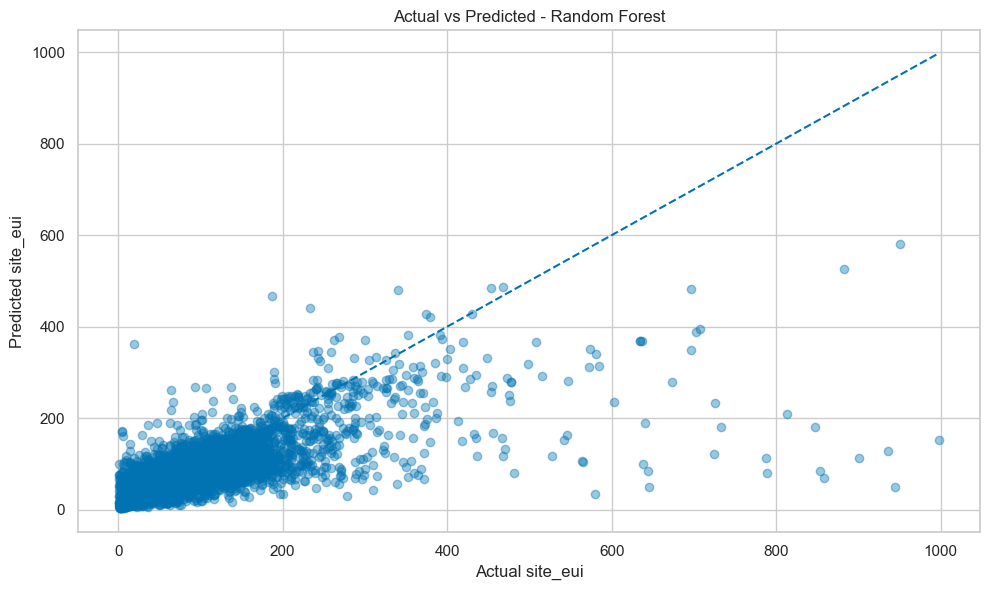

In [436]:
# Actual vs Predicted - Random Forest

actual_rf = np.expm1(y_test)
predicted_rf = np.expm1(y_pred_rf_tune_log)

plt.figure(figsize=(10, 6))

plt.scatter(
    actual_rf,
    predicted_rf,
    alpha=0.4
)

min_value = min(actual_rf.min(), predicted_rf.min())
max_value = max(actual_rf.max(), predicted_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual site_eui")
plt.ylabel("Predicted site_eui")
plt.title("Actual vs Predicted - Random Forest")

plt.tight_layout()
plt.show()

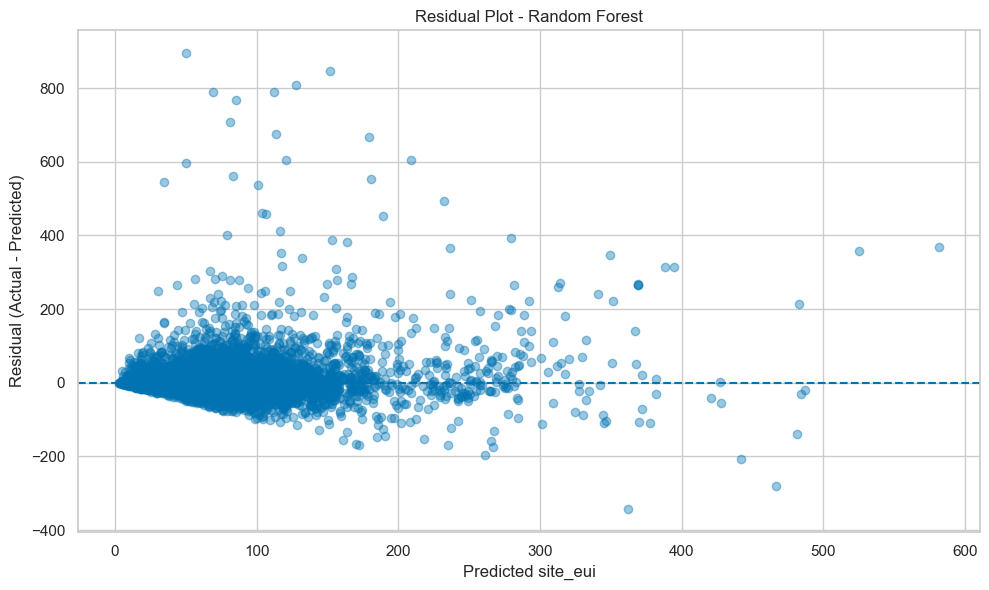

In [437]:
# Residual Plot - Random Forest

residuals_rf = actual_rf - predicted_rf

plt.figure(figsize=(10, 6))

plt.scatter(
    predicted_rf,
    residuals_rf,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted site_eui")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Random Forest")

plt.tight_layout()
plt.show()

## Feature Importance - Random Forest

Feature importance shows which input features contribute most to the Random Forest model's predictions of building energy consumption.

In [438]:
# Feature Importance - Random Forest

# Get the trained Random Forest model
rf_model = best_rf.named_steps['model']

# Get the preprocessing pipeline
rf_preprocessor = best_rf.named_steps['preprocessor']

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance values
feature_importance = rf_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 features
display(importance_df.head(15).round(4))

,Feature,Importance
0,num__energy_star_rating,0.2503
56,num__floor_area_log,0.1838
55,num__age_of_building,0.1195
3,num__january_avg_temp,0.0445
124,cat__facility_type_Warehouse_Nonrefrigerated,0.0434
126,cat__facility_type_Warehouse_Selfstorage,0.0357
81,cat__facility_type_Grocery_store_or_food_market,0.0254
1,num__ELEVATION,0.0229
2,num__january_min_temp,0.0227
82,cat__facility_type_Health_Care_Inpatient,0.0178


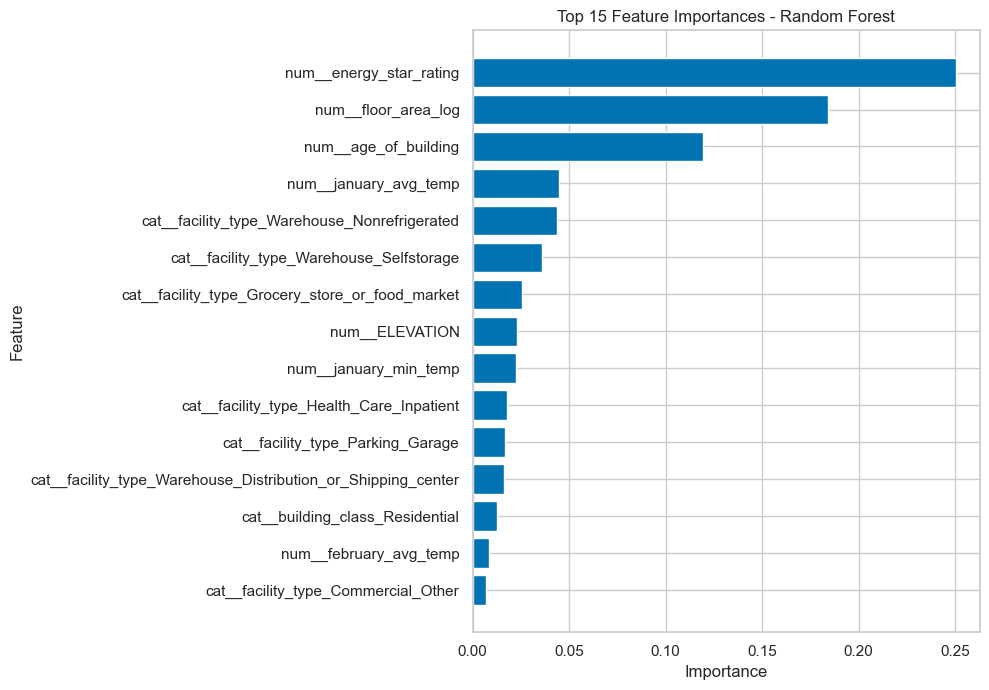

In [439]:
# Plot Top 15 Feature Importances

top_features = importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()